# Entregável 2: Avaliação da Qualidade do Sinal (SQI)
**Disciplina:** Aquisição e Processamento de Biossinais  
**Equipe:** José Ferreira Lessa & Matheus Rocha Gomes da Silva  
**Orientador:** Prof. Dr. Victor Hugo C. de Albuquerque  
**Dataset:** PTB-XL — A Large Publicly Available Electrocardiography Dataset (PhysioNet)  
**Referência:** Wagner et al. (2020). PTB-XL, a large publicly available electrocardiography dataset. *Scientific Data*, 7(1), 154.  
**Data:** Março e Abril de 2026

---

## Objetivo

Este notebook descreve a etapa de **Avaliação de Qualidade dos Biossinais**, com foco na quantificação da qualidade dos sinais de ECG do dataset PTB-XL por meio de índices objetivos. O objetivo é identificar registros adequados para análise clínica e modelagem, bem como detectar sinais degradados por ruídos ou artefatos. São abordados:

1. **Estratégia de Amostragem para Cálculo do SQI:** Função de carregamento de dataset, análise de metadados referentes à qualidade dos sinais e função de processamento mínimo.
2. **Implementação das Métricas de SQI:** métricas de ordem superior, no domínio da frequência, de continuidade e morfologia e multicanais. Com extração das métricas e análise exploratória de cada.
3. **Carregamento dos Sinais de ECG:** Cálculo do Score por Gatekeeper, otimização dos limiares por evidência empírica e validação da análise de qualidade.
4. **Visualizações Comparativas:** Comparação entre classes de qualidade, matriz de correlação entre métricas, SNR por categoria e derivação.
5. **Salvamento e Síntese:** Contagem de registros por classe, tabela expositiva do resultado do SQI e salvamento de novo banco de dados sem sinais rejeitados + outro com apenas sinais rejeitados.


> **Nota metodológica:** A avaliação de qualidade é realizada diretamente sobre os sinais brutos, sem aplicação de etapas de pré-processamento corretivo. Essa escolha permite caracterizar fielmente as condições originais de aquisição e identificar artefatos reais presentes nos registros.

A saída deste notebook consiste em um conjunto de métricas de qualidade associadas a cada registro, que poderão ser utilizadas para filtragem, análise exploratória e suporte às etapas posteriores do pipeline.

## 1. Importações e Dependências
Além dos pacotes já anteriormente usados, importamos 
* `scipy.stats` para kurtosis e skewness e 
* `tqdm` para acompanhamento da barra de progresso no processamento em lote.

In [33]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import scipy.signal as signal
import scipy.stats as stats                   # Novo em Relação ao Entregável 1
from pathlib import Path
from tqdm import tqdm                # Novo em Relação ao Entregável 1
from IPython.display import display, Markdown
#from collections import Counter             # não utilizado aqui
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

np.random.seed(42)

## 2. Configurações Globais

In [2]:
FS = 100
N_LEADS = 12
LEAD_NAMES = ['I', 'II', 'III', 'aVL', 'aVR', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
FOLDS_TREINO = [1, 2, 3, 4, 5, 6, 7, 8]
FOLD_VAL = 9
FOLD_TEST = 10

DATA_DIR = '../../../data/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/'
FIGS_DIR = Path('../figuras')
OUT_DIR  = Path('../outputs')
for d in [FIGS_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Configuração concluída.')
print(f'Figuras em: {FIGS_DIR.resolve()}')
print(f'Outputs em: {OUT_DIR.resolve()}')

Configuração concluída.
Figuras em: C:\Users\User\Desktop\repo-lessa\entregaveis\entregavel-2\figuras
Outputs em: C:\Users\User\Desktop\repo-lessa\entregaveis\entregavel-2\outputs


## 3. Carregamento dos Metadados Enriquecidos
Partimos do arquivo gerado no Entregável 1, que já contém as colunas de superclasse diagnóstica, ritmos, formas, split e flags de qualidade.

In [3]:
print("Carregando metadados do Entregável 1...")
caminho_metadados = '../../entregavel-1/outputs/ptbxl_metadata_enriched.csv'

if not os.path.exists(caminho_metadados):
    raise FileNotFoundError(f"Arquivo não encontrado: {caminho_metadados}\nExecute o Entregável 1 primeiro.")

df = pd.read_csv(caminho_metadados, index_col='ecg_id')
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)
df['superclasses_clean'] = df['superclasses_clean'].apply(ast.literal_eval)

scp_statements = pd.read_csv(os.path.join(DATA_DIR, 'scp_statements.csv'), index_col=0)

print(f"Dataset carregado: {df.shape[0]} registros, {df.shape[1]} colunas.")

Carregando metadados do Entregável 1...
Dataset carregado: 21799 registros, 34 colunas.


---
## Seção 1 — Estratégia de Amostragem para Cálculo do SQI


### 1.1 Processamento em Lote

Nesta etapa, definimos uma função utilitária responsável por carregar os sinais de ECG diretamente dos arquivos no formato WFDB.

O objetivo é permitir a leitura eficiente dos registros a partir de seus identificadores (`ecg_id`), convertendo-os em arrays NumPy que poderão ser utilizados nas etapas posteriores de cálculo dos índices de qualidade (SQI).

A função considera a frequência de amostragem desejada (100 Hz ou 500 Hz), garantindo consistência na análise mesmo que a frequência FS seja diferente da usada durante a elaboração do pipeline.

In [4]:
def load_ecg(ecg_id, dataframe, path_base, fs):
    """
    Carrega o sinal de ECG a partir dos arquivos WFDB do PTB-XL.

    Parâmetros:
    - ecg_id: identificador do exame no dataframe
    - dataframe: tabela com os metadados (df)
    - path_base: caminho base onde estão os arquivos .dat/.hea
    - fs: frequência de amostragem desejada (100 ou 500 Hz)

    Retorna:
    - sig_arr: array NumPy com o sinal (n_amostras x 12 derivações)
    """

    # Seleciona a linha correspondente ao ECG
    linha = dataframe.loc[ecg_id]

    # Escolhe o arquivo correto conforme a frequência
    file_target = linha['filename_lr'] if fs == 100 else linha['filename_hr']

    # Lê o sinal utilizando WFDB
    signal_arr, _ = wfdb.rdsamp(os.path.join(path_base, file_target))

    return signal_arr

### 1.2 Verificação de Consistência dos Metadados de Qualidade

Antes de calcular os índices de qualidade, é importante avaliar a distribuição das anotações de qualidade já disponíveis no dataset.

O PTB-XL inclui flags indicando possíveis problemas no sinal (como *baseline drift*, ruído estático e problemas de eletrodo). Embora essas anotações não sejam utilizadas diretamente como rótulos no cálculo do SQI, elas servem como referência para validação posterior.

Nesta etapa, analisamos:
- A proporção de registros com e sem problemas de qualidade
- A distribuição desses problemas entre os diferentes *folds*

Isso permite identificar possíveis vieses de coleta ou concentração de ruído em subconjuntos específicos do dataset.

In [5]:
# Contagem de registros com/sem problemas de qualidade
qtd_issues = df['has_quality_issues'].value_counts()

# Percentual de registros "limpos"
pct_limpos = (qtd_issues.get(False, 0) / len(df)) * 100

display(Markdown(f"""
**Resumo dos metadados de qualidade originais:**
- **{pct_limpos:.2f}%** dos registros não possuem nenhuma anotação de problema de qualidade.
- Os demais possuem ao menos um indicador de possível degradação do sinal (baseline drift, ruído, etc.).
"""))

# Tabela cruzada por fold
display(Markdown("**Tabela cruzada: problemas de qualidade por fold:**"))
display(pd.crosstab(df['has_quality_issues'], df['strat_fold'], margins=True))


**Resumo dos metadados de qualidade originais:**
- **77.02%** dos registros não possuem nenhuma anotação de problema de qualidade.
- Os demais possuem ao menos um indicador de possível degradação do sinal (baseline drift, ruído, etc.).


**Tabela cruzada: problemas de qualidade por fold:**

strat_fold,1,2,3,4,5,6,7,8,9,10,All
has_quality_issues,,,,,,,,,,,
False,1665,1714,1664,1719,1677,1678,1678,1685,1639,1670,16789
True,510,467,528,455,497,495,498,488,544,528,5010
All,2175,2181,2192,2174,2174,2173,2176,2173,2183,2198,21799


**Comentários sobre a subseção 1.2:**

Observa-se que a maior parte do dataset (**77.02% dos registros**) não apresenta qualquer anotação de problema de qualidade, indicando que, em termos gerais, o PTB-XL possui uma base majoritariamente limpa do ponto de vista dos metadados disponíveis.

Ao analisar a distribuição por *fold*, nota-se que os registros com problemas de qualidade estão **relativamente bem distribuídos entre os 10 folds**, sem concentração evidente em um subconjunto específico. Cada fold apresenta proporções semelhantes de registros com e sem anotações de ruído.

Essa uniformidade sugere que não há viés significativo de qualidade associado à divisão dos dados, o que é desejável para garantir a consistência de análises posteriores e evitar distorções entre conjuntos de treino, validação e teste.

### 1.3 Processamento Mínimo para Equilíbrio das Análises

Para o cálculo dos índices de qualidade (SQI), é necessário aplicar um processamento mínimo nos sinais de ECG, com o objetivo de evitar vieses numéricos nas métricas.

É importante destacar que esta etapa **não tem como objetivo melhorar a qualidade do sinal**, mas sim garantir que as medidas estatísticas e espectrais sejam comparáveis entre registros.

As transformações aplicadas devem ser:
- **Neutras** do ponto de vista clínico
- **Não destrutivas**
- **Consistentes entre todos os registros**

Neste contexto, são adotadas operações simples como:
- Remoção de média (centralização do sinal)
- Normalização por desvio padrão (*z-score*)

Essas operações evitam que diferenças de escala ou offset influenciem indevidamente métricas como kurtosis, energia espectral ou correlação entre derivações.

In [6]:
def minimal_preprocess(sig):
    """
    Aplica um processamento mínimo no sinal de ECG para estabilizar métricas de SQI.

    Etapas:
    - Remoção da média (baseline constante)
    - Normalização (z-score)

    IMPORTANTE:
    Não remove ruído, não filtra e não altera a morfologia clínica do sinal.
    """

    # Remove média (baseline constante)
    sig = sig - np.mean(sig, axis=0)

    # Normalização por desvio padrão (evita divisão por zero)
    std = np.std(sig, axis=0)
    std[std == 0] = 1

    sig = sig / std

    return sig

Contudo, no artigo [Towards_High-Fidelity_ECG_Generation_Evaluation_via_Quality_Metrics_and_Human_Feedback](../../../docs/research/Towards_High-Fidelity_ECG_Generation_Evaluation_via_Quality_Metrics_and_Human_Feedback.pdf), é comentado como o dataset utilizado neste projeto já passou por etapas de pré-processamento e as duas "transformações" executadas pelo código acima já foram implementadas nos dados brutos disponíveis.

Em razão disso, a função acabará por não ser implementada durante a execução do projeto, mas optamos por deixá-la transcrita por motivos de curiosidade ( se você o está rodando e quer deixar mais leve, pode simplesmente ignorar/apagar a célula acima ).

---
## Seção 2 — Implementação das Métricas de SQI

Nesta seção, são implementadas as métricas utilizadas para avaliação da qualidade dos sinais de ECG, com base em abordagens consolidadas na literatura.

Os índices de qualidade (*Signal Quality Indices — SQI*) são calculados **individualmente para cada uma das 12 derivações**, permitindo uma análise detalhada da integridade do sinal em nível local.

As métricas foram organizadas em quatro categorias principais:

1. **Estatísticas de Ordem Superior:** Avaliam a forma da distribuição do sinal no domínio do tempo, incluindo *kurtosis* e *skewness*, combinadas no índice **hosSQI**.
2. **Domínio da Frequência:** Avaliam a distribuição de energia espectral, incluindo o **pSQI** (banda do QRS), o **basSQI** (influência de ruído de baixa frequência) e métricas de análise de sinal típicas e globais, como **SNR** (Signal-to-Noise Ratio) e **Entropia Espectral** (mede o quão organizado ou não o padrão do sinal é).
3. **Continuidade e Morfologia:** Avaliam características estruturais do sinal, como o **Flat Ratio** e o **qSQI**, relacionados à presença de artefatos e consistência dos batimentos.
4. **Métrica Multicanal:** Avalia a consistência entre derivações através do **rinter**, baseado na correlação entre canais.

Essas métricas, quando combinadas, permitem uma avaliação robusta e interpretável da qualidade dos sinais.

### 2.1 Estatísticas de Ordem Superior

As estatísticas de ordem superior permitem avaliar a distribuição do sinal no domínio do tempo, capturando desvios em relação ao comportamento esperado de um ECG fisiológico.

- **Skewness (sSQI):** mede a assimetria da distribuição
- **Kurtosis (kSQI):** mede o grau de concentração (picos) da distribuição

A partir dessas métricas, define-se o índice combinado:

$hosSQI = \frac{|sSQI| \times kSQI}{5}$


Esse índice tende a assumir valores mais altos em sinais com morfologia consistente e menor presença de ruído.

---


**Referências:**
- [A_tool_for_the_real-time_evaluation_of_ECG_signal_quality_and_activity_--_Application_to_submaximal_treadmill_test in_horses.pdf](../../../docs/research/A_tool_for_the_real-time_evaluation_of_ECG_signal_quality_and_activity_--_Application_to_submaximal_treadmill_test%20in_horses.pdf)

In [7]:
def compute_hos_sqi(sig):
    """
    Calcula sSQI, kSQI e hosSQI para cada derivação.
    """

    sSQI = stats.skew(sig, axis=0)
    kSQI = stats.kurtosis(sig, axis=0, fisher=False)

    # Uma vez que hosSQI maiores que 0.8 já podem ser considerados excelentes, 
    # cliparemos os valores para no máximo 10 a fim de não haverem explosões
    # (o que potencialmente pode indicar sinais ruidosos, mas isso poderá ser 
    # atestado analisando a métrica pSQI --- Se for baixa enquanto o hosSQI é 
    # alto, o sinal é ruído puro)
    hosSQI = np.minimum((np.abs(sSQI) * kSQI) / 5, 10) 

    return sSQI, kSQI, hosSQI

### 2.2 Métricas no Domínio da Frequência e Qualidade Global

Além das métricas clássicas baseadas na distribuição de energia espectral (como pSQI e basSQI), incorporamos métricas adicionais que permitem avaliar a qualidade global do sinal de forma mais robusta.

- **pSQI (Power SQI):** avalia a concentração de energia na banda do QRS (5–15 Hz) em relação à energia total na faixa de interesse (5-40 Hz), refletindo a presença de atividade cardíaca bem definida. Com ela, ruído muscular de alta frequência pode ser identificado.
- **basSQI (Baseline SQI):** mede a proporção de energia acima de 1 Hz em relação à banda total (0–40 Hz), sendo sensível a deriva de linha de base (baseline wander).

Como complemento, foram incluídas métricas amplamente utilizadas em processamento de sinais:

- **SNR (Signal-to-Noise Ratio):** quantifica a razão entre a potência do sinal filtrado (0.5–40 Hz) e o ruído residual. Valores mais altos indicam melhor qualidade global do sinal.
- **Entropia Espectral:** mede o grau de desorganização do espectro de frequências. Sinais limpos tendem a apresentar energia concentrada (baixa entropia), enquanto sinais ruidosos apresentam espectro mais uniforme (alta entropia).

> **Observação:** A análise explícita de interferência de rede elétrica (50 Hz) não foi incluída, pois, com frequência de amostragem de 100 Hz, essa componente situa-se no limite de Nyquist (fs/2), tornando sua detecção pouco confiável.

---

**Referências:**
- [A_tool_for_the_real-time_evaluation_of_ECG_signal_quality_and_activity_--_Application_to_submaximal_treadmill_test in_horses.pdf](../../../docs/research/A_tool_for_the_real-time_evaluation_of_ECG_signal_quality_and_activity_--_Application_to_submaximal_treadmill_test%20in_horses.pdf)
- [SQI_Quality_Evaluation_Mechanism_of_Single-Lead_ECG_Signal_Based_on_Simple_Heuristic_Fusion_and_Fuzzy_Comprehensive_Evaluation](../../../docs/research/SQI_Quality_Evaluation_Mechanism_of_Single-Lead_ECG_Signal_Based_on_Simple_Heuristic_Fusion_and_Fuzzy_Comprehensive_Evaluation.pdf)
- [A_Novel_Method_and_Python_Library_for_ECG_Signal_Quality_Assessment](../../../docs/research/A_Novel_Method_and_Python_Library_for_ECG_Signal_Quality_Assessment.pdf)
- [EcgScorer_-_An_open_source_MATLAB_toolbox_for_ECG_signal](../../../docs/research/EcgScorer_-_An_open_source_MATLAB_toolbox_for_ECG_signal.pdf)

In [8]:
def compute_freq_sqi(sig, fs):
    """
    Calcula pSQI e basSQI para cada derivação usando o método de Welch.
    """

    psqi_list = []
    bassqi_list = []

    for i in range(sig.shape[1]):
        # PSD via Welch
        freqs, psd = signal.welch(sig[:, i], fs=fs, nperseg=256)

        # Máscaras de frequência
        mask_qrs = (freqs >= 5) & (freqs <= 15)
        mask_5_40 = (freqs >= 5) & (freqs <= 40)
        mask_above_1 = (freqs >= 1)
        mask_0_40 = (freqs <= 40)

        # Energias (integração via soma)
        energy_qrs = np.sum(psd[mask_qrs])
        energy_5_40 = np.sum(psd[mask_5_40])
        energy_above_1 = np.sum(psd[mask_above_1])
        energy_0_40 = np.sum(psd[mask_0_40])

        # Evitar divisão por zero
        psqi = energy_qrs / energy_5_40 if energy_5_40 > 0 else 0
        bassqi = energy_above_1 / energy_0_40 if energy_0_40 > 0 else 0

        psqi_list.append(psqi)
        bassqi_list.append(bassqi)

    return np.array(psqi_list), np.array(bassqi_list)

In [9]:
def compute_snr(sig, fs=FS):
    nyq = 0.5 * fs
    b, a = signal.butter(4, [0.5/nyq, 40/nyq], btype='bandpass')
    s_clean = signal.filtfilt(b, a, sig, axis=0)
    noise = sig - s_clean

    rms_clean = np.sqrt(np.mean(s_clean**2, axis=0))
    rms_noise = np.sqrt(np.mean(noise**2, axis=0))

    # Proteção numérica, adicionada após execução da função e divisão por zero encontrada
    eps = 1e-10
    rms_clean = np.maximum(rms_clean, eps)
    rms_noise = np.maximum(rms_noise, eps)

    snr_db = 10 * np.log10((rms_clean**2) / (rms_noise**2))

    # Limita valores absurdos sem impedir sinais ruins de terem resultados ruins
    snr_db = np.clip(snr_db, -20, 60)

    return np.median(snr_db)

def compute_spectral_entropy(sig, fs=FS):
    """
    Entropia espectral média entre as 12 derivações.
    Sinal limpo = espectro concentrado = entropia baixa.
    Ruído branco = espectro plano = entropia alta (~1).
    """
    entropies = []

    for i in range(sig.shape[1]):  # percorre as 12 derivações
        lead = sig[:, i]
        freqs, psd = signal.welch(lead, fs=fs, nperseg=256)

        psd_sum = np.sum(psd)
        if psd_sum == 0:
            continue  # evita divisão por zero

        psd_norm = psd / psd_sum
        H = -np.sum(psd_norm * np.log2(psd_norm + 1e-10))
        H_norm = H / np.log2(len(psd))

        entropies.append(H_norm)

    return np.mean(entropies) if entropies else 1.0  # máximo ruído

### 2.3 Métricas de Continuidade e Morfologia

Essas métricas avaliam a integridade estrutural do sinal no domínio do tempo, identificando comportamentos anômalos que podem indicar problemas de aquisição.

- **Flat Ratio:** mede a proporção de amostras praticamente constantes ao longo do tempo, sendo útil para detectar saturação do sinal ou perda de contato de eletrodos.
- **qSQI:** avalia a consistência na detecção de complexos QRS, funcionando como um indicador indireto da qualidade morfológica do sinal.

Em implementações completas, o qSQI é calculado como a concordância entre diferentes detectores de batimento (ex: Pan-Tompkins e Wavelets). Neste trabalho, utilizamos uma aproximação baseada na regularidade dos intervalos RR, que captura o mesmo princípio de consistência dos batimentos.

---

**Referências:**
- [EcgScorer_-_An_open_source_MATLAB_toolbox_for_ECG_signal](../../../docs/research/EcgScorer_-_An_open_source_MATLAB_toolbox_for_ECG_signal.pdf)
- [SQI_Quality_Evaluation_Mechanism_of_Single-Lead_ECG_Signal_Based_on_Simple_Heuristic_Fusion_and_Fuzzy_Comprehensive_Evaluation](../../../docs/research/SQI_Quality_Evaluation_Mechanism_of_Single-Lead_ECG_Signal_Based_on_Simple_Heuristic_Fusion_and_Fuzzy_Comprehensive_Evaluation.pdf)

In [10]:
def compute_flatline_sqi(sig, fs, threshold=1e-3, min_duration=1.5):
    """
    Flat SQI (baseado na literatura + abordagem contínua).

    Métricas:
    - flat_ratio: proporção total de trechos quase constantes
    - has_flatline: detecta se existe segmento contínuo >= 1.5s ( como descrito no EcgScorer )

    Parâmetros:
    - threshold: limite para considerar variação como "flat"
    - min_duration: duração mínima (em segundos) para evento crítico
    """

    flat_ratios = []
    flatline_flags = []

    min_samples = int(min_duration * fs)

    for i in range(sig.shape[1]):
        lead = sig[:, i]

        # Derivada absoluta
        diff = np.abs(np.diff(lead))

        # Máscara de regiões "flat"
        flat_mask = diff < threshold

        # -------------------------
        # 1. Flat ratio (global)
        # -------------------------
        flat_ratio = np.sum(flat_mask) / len(flat_mask)

        # -------------------------
        # 2. Detecção de sequência contínua
        # -------------------------
        max_len = 0
        current_len = 0

        for val in flat_mask:
            if val:
                current_len += 1
                max_len = max(max_len, current_len)
            else:
                current_len = 0

        has_flatline = max_len >= min_samples

        flat_ratios.append(flat_ratio)
        flatline_flags.append(int(has_flatline))

    return np.array(flat_ratios), np.array(flatline_flags)

In [11]:
def compute_qsqi(sig, fs):
    """
    Aproximação de qSQI baseada na regularidade dos picos R.

    Mede a consistência dos intervalos RR.
    """

    qsqi_list = []

    for i in range(sig.shape[1]):
        lead = sig[:, i]

        # Detecta picos simples (não clínico, mas suficiente para SQI)
        peaks, _ = signal.find_peaks(lead, distance=fs*0.4)

        if len(peaks) < 3:
            qsqi_list.append(0)
            continue

        rr_intervals = np.diff(peaks) / fs

        # Variabilidade relativa
        rr_std = np.std(rr_intervals)
        rr_mean = np.mean(rr_intervals)

        qsqi = 1 - (rr_std / rr_mean) if rr_mean > 0 else 0
        qsqi = max(0, qsqi)  # evita valores negativos

        qsqi_list.append(qsqi)

    return np.array(qsqi_list)

### 2.4 Métrica Multicanal ($r_{inter}$)

Diferentemente das métricas anteriores, que avaliam cada derivação individualmente, o **rinter** mede a consistência entre as diferentes derivações do ECG.

Ele é baseado na correlação de Pearson entre os canais, capturando o grau de similaridade entre os sinais.

Essa métrica é especialmente importante para detectar:
- Falhas em eletrodos específicos
- Problemas de conexão em canais isolados
- Inconsistências multicanais

Valores altos de rinter indicam coerência entre derivações, enquanto valores baixos podem sugerir problemas localizados.

---

**Referências:**
- [A_Novel_Method_and_Python_Library_for_ECG_Signal_Quality_Assessment](../../../docs/research/A_Novel_Method_and_Python_Library_for_ECG_Signal_Quality_Assessment.pdf)

In [12]:
def compute_rinter(sig):
    n_leads = sig.shape[1]
    correlations = []

    for i in range(n_leads):
        for j in range(i + 1, n_leads):

            std_i = np.std(sig[:, i])
            std_j = np.std(sig[:, j])

            # ignora sinais constantes, evitando erro de std = 0
            if std_i < 1e-6 or std_j < 1e-6:
                continue

            corr = np.corrcoef(sig[:, i], sig[:, j])[0, 1]

            if not np.isnan(corr):
                correlations.append(corr)

    return np.mean(correlations) if correlations else 0

### 2.5 Extração em Lote das Métricas de Qualidade (SQI)

Com todas as métricas definidas, foi realizada a extração em lote dos índices de qualidade para **todos os registros do dataset**. Para cada ECG, o sinal bruto das 12 derivações é carregado e processado individualmente, sendo então calculadas as métricas propostas ao longo desta seção.

Cada métrica é inicialmente computada **por derivação**, respeitando a natureza multicanal do ECG. Em seguida, é aplicada uma etapa de **agregação**, convertendo os 12 valores em um único indicador representativo por registro. Essa abordagem segue recomendações da literatura, permitindo avaliar a qualidade global do exame sem perder a sensibilidade a problemas localizados.

As métricas extraídas para cada registro incluem:

- **Estatísticas de ordem superior:**  
  - `hosSQI` (composição de skewness e kurtosis), representado por média e mediana entre derivações.

- **Domínio da frequência:**  
  - `pSQI` (energia na banda do QRS, 5–15 Hz)  
  - `basSQI` (relação entre energia acima de 1 Hz e banda total)

- **Relação sinal-ruído:**  
  - `SNR (dB)`, estimado via comparação entre sinal filtrado (0.5–40 Hz) e ruído residual.

- **Complexidade espectral:**  
  - `Entropia espectral`, calculada como média entre as derivações.

- **Continuidade do sinal:**  
  - `flat_ratio` (proporção de trechos quase constantes)  
  - `has_flatline` (detecção de segmentos contínuos ≥ 1.5s)

- **Regularidade dos batimentos:**  
  - `qSQI`, baseado na variabilidade dos intervalos RR.

- **Consistência multicanal:**  
  - `rinter`, definido como a correlação média entre pares de derivações válidas.

Durante o processamento, foram aplicadas **correções numéricas robustas** para evitar instabilidades computacionais (como divisões por zero ou valores indefinidos). Essas correções não alteram a interpretação clínica das métricas, apenas garantem que o pipeline seja executado de forma estável em todo o dataset.

Ao final, os resultados são organizados em um novo dataframe (`df_sqi`), contendo **uma linha por registro**, com todas as métricas agregadas. Esse conjunto de dados servirá como base para a etapa seguinte, onde será implementada a lógica de classificação da qualidade dos sinais.

> **Nota metodológica:** sinais degenerados (ex: flatlines) não são “corrigidos” ou descartados nesta etapa. Pelo contrário, são preservados e corretamente penalizados pelas métricas, garantindo que o índice de qualidade reflita fielmente as condições reais de aquisição do sinal.

In [13]:
# Extração em Lote das Métricas sobre Dataset Inteiro

results = []

for eid in tqdm(df.index, desc='Calculando métricas SQI', unit='sinal'):
    try:
        sig = load_ecg(eid, df, DATA_DIR, FS)

        # -------------------------
        # 1. HOS SQI
        # -------------------------
        sSQI, kSQI, hosSQI = compute_hos_sqi(sig)

        # -------------------------
        # 2. Frequência SQI
        # -------------------------
        pSQI, basSQI = compute_freq_sqi(sig, FS)

        # -------------------------
        # 3. SNR
        # -------------------------
        snr = compute_snr(sig, FS)

        # -------------------------
        # 4. Entropia espectral
        # -------------------------
        entropy = compute_spectral_entropy(sig, FS)

        # -------------------------
        # 5. Flatline
        # -------------------------
        flat_ratio, flat_flag = compute_flatline_sqi(sig, FS)

        # -------------------------
        # 6. qSQI
        # -------------------------
        qsqi = compute_qsqi(sig, FS)

        # -------------------------
        # 7. rinter
        # -------------------------
        rinter = compute_rinter(sig)

        # -------------------------
        # Agregação (nível registro)
        # -------------------------
        results.append({
            'ecg_id': eid,

            # HOS
            'hosSQI_mean': np.mean(hosSQI),
            'hosSQI_median': np.median(hosSQI),

            # Frequência
            'pSQI_mean': np.mean(pSQI),
            'basSQI_mean': np.mean(basSQI),

            # SNR
            'snr_db': snr,

            # Entropia
            'spectral_entropy': entropy,

            # Flatline
            'flat_ratio_max': np.max(flat_ratio),
            'has_flatline': int(np.any(flat_flag)),

            # qSQI
            'qSQI_mean': np.mean(qsqi),

            # Multicanal
            'rinter': rinter
        })

    except Exception as e:
        print(f"Erro no ECG ID {eid}: {e}")

# Criar DataFrame final
df_sqi = pd.DataFrame(results).set_index('ecg_id')

print(f"Métricas calculadas para {len(df_sqi)} registros.")

Calculando métricas SQI: 100%|██████████| 21799/21799 [28:48<00:00, 12.61sinal/s] 


Métricas calculadas para 21799 registros.


### 2.6 Análise Exploratória das Métricas de Qualidade (SQI)

Antes de combinar as métricas em um índice global de qualidade, é fundamental analisar a **distribuição individual de cada métrica** ao longo do dataset. Essa etapa permite compreender o comportamento estatístico dos indicadores, identificar valores extremos e validar empiricamente os limiares que serão utilizados na etapa de classificação.

A análise é realizada sobre o dataframe `df_sqi`, contendo uma linha por registro e as métricas já agregadas entre as 12 derivações. São observadas tanto a dispersão quanto a concentração dos valores, permitindo responder questões como:

- As métricas apresentam distribuição unimodal ou multimodal?
- Existem caudas longas ou outliers relevantes?
- Há concentração significativa em regiões críticas (ex: SNR baixo, alta entropia, flatline)?

Para isso, são utilizados histogramas com estimativa de densidade (KDE), que facilitam a visualização da forma da distribuição. Essa análise não apenas orienta a escolha de thresholds, mas também serve como validação qualitativa do comportamento esperado das métricas de SQI no contexto do PTB-XL.

> **Nota:** métricas com comportamento anômalo (ex: valores concentrados em extremos ou distribuições degeneradas) podem indicar problemas de implementação ou características específicas do dataset que devem ser consideradas na etapa de decisão.

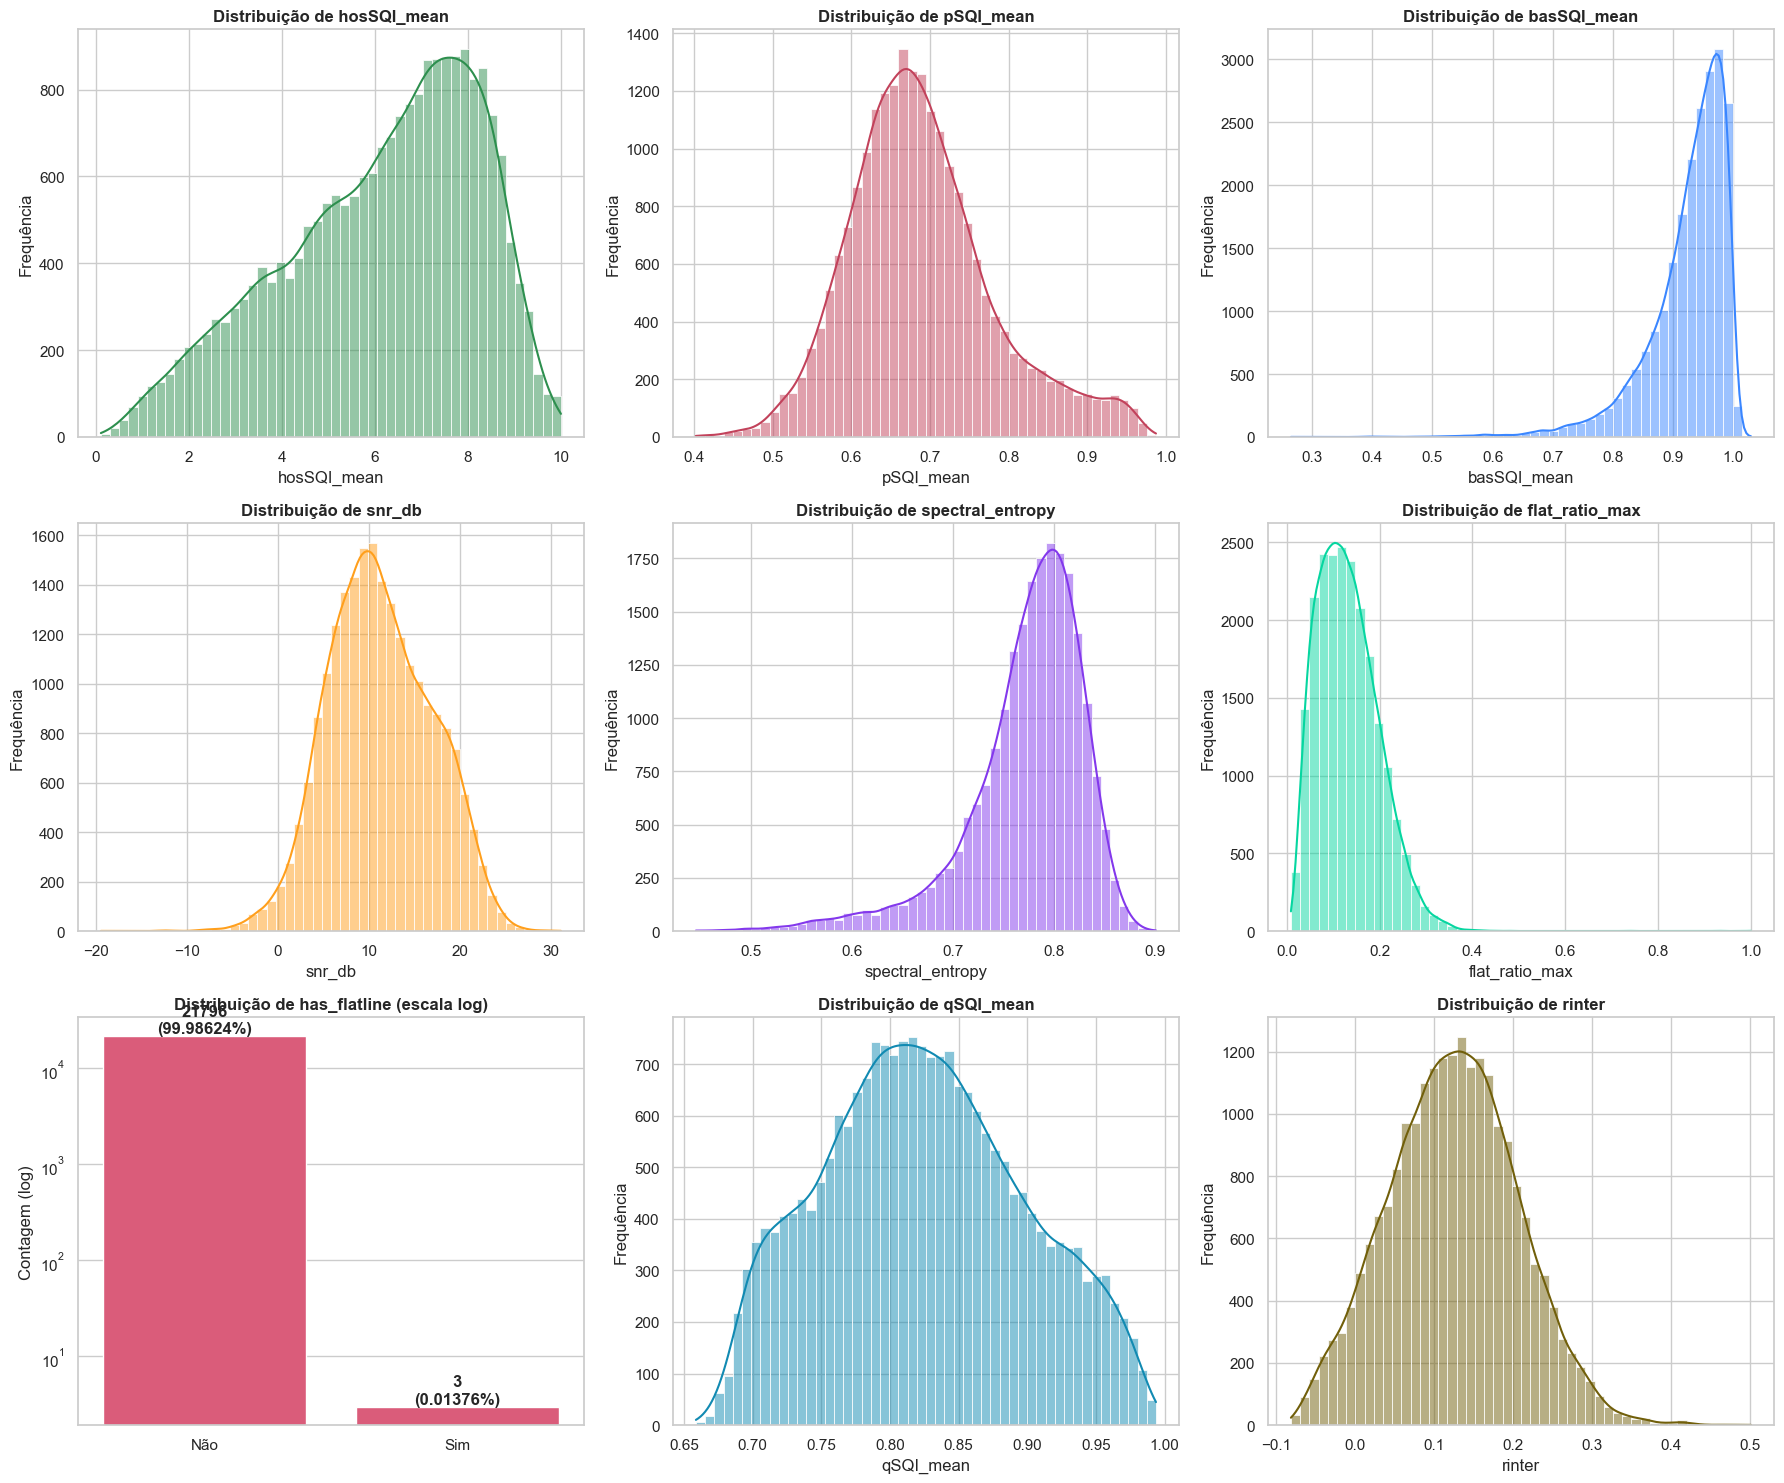

In [14]:
# 2.6 Distribuição das Métricas SQI (com cores)

metricas = [
    'hosSQI_mean',
    'pSQI_mean',
    'basSQI_mean',
    'snr_db',
    'spectral_entropy',
    'flat_ratio_max',
    'has_flatline',
    'qSQI_mean',
    'rinter'
]

cores = [
    '#2d8f4e',  # verde
    '#c2425b',  # vermelho
    '#3a86ff',  # azul
    '#ff9f1c',  # laranja
    '#8338ec',  # roxo
    '#06d6a0',  # verde água
    '#ef476f',  # rosa
    '#118ab2',  # azul petróleo
    '#715f0A'   # amarelo escuro
]

n_cols = 3
n_rows = int(np.ceil(len(metricas) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

df_sqi[metricas].describe()

for i, metric in enumerate(metricas):
    if metric == 'has_flatline':
        counts = df_sqi['has_flatline'].value_counts().sort_index()
        total = len(df_sqi)

        for j, v in enumerate(counts.values):
            perc = 100 * v / total
            axes[i].text(j, v, f'{v}\n({perc:.5f}%)', ha='center', va='bottom', fontweight='bold')
        
        sns.barplot(
            x=['Não', 'Sim'],
            y=counts.values,
            ax=axes[i],
            color=cores[i]
        )

        axes[i].set_yscale('log')
        axes[i].set_title('Distribuição de has_flatline (escala log)', fontweight='bold')
        axes[i].set_ylabel('Contagem (log)')
        continue

    sns.histplot(
        df_sqi[metric],
        bins=50,
        kde=True,
        color=cores[i],
        ax=axes[i]
    )
    
    axes[i].set_title(f'Distribuição de {metric}', fontweight='bold')
    axes[i].set_xlabel(metric)
    axes[i].set_ylabel('Frequência')

# Remove eixos vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'distribuicao_metricas_sqi.png'), dpi=150, bbox_inches='tight')
plt.show()

---

## Seção 3 — SQI Composto e Critério de Decisão

Após a extração individual das métricas de qualidade, o próximo passo consiste em combiná-las em um **índice composto de qualidade (SQI)** refinada capaz de classificar automaticamente os registros de ECG em diferentes níveis de confiabilidade, baseada em evidências da literatura e em observações empíricas do dataset PTB-XL.

Diferentemente de abordagens baseadas em uma única métrica, esta seção adota uma estratégia de **fusão heurística multi-métrica**, amplamente utilizada na literatura para avaliação de sinais biomédicos. Essa abordagem permite capturar diferentes dimensões da qualidade do sinal — incluindo morfologia, estrutura espectral, continuidade e consistência multicanal — resultando em um sistema mais robusto e interpretável.

O método implementado segue a lógica de um sistema **"Gatekeeper"**, no qual critérios críticos são avaliados inicialmente para excluir sinais claramente inválidos, seguidos por uma etapa de avaliação de sinais que precisem de processamento futuro e findando em uma etapa de decisão baseada em múltiplos limiares. Essa estrutura é particularmente adequada ao dataset PTB-XL, que apresenta características de aquisição do mundo real, incluindo presença de ruídos e artefatos. [[R3.1]](../../../docs/research/A_tool_for_the_real-time_evaluation_of_ECG_signal_quality_and_activity_--_Application_to_submaximal_treadmill_test%20in_horses.pdf)

Inicialmente, a estratégia de classificação adotava critérios bastante rigorosos, o que levou a uma taxa elevada de rejeição de sinais. No entanto, a literatura indica que nem todo sinal degradado deve ser descartado: muitos podem ser recuperados por técnicas de processamento de sinais.

Dessa forma, esta seção introduz um modelo de decisão mais realista e clinicamente relevante, baseado em três conceitos fundamentais:

- **Sinais inválidos (U):** sem informação útil (ex: saturação)
- **Sinais recuperáveis (P):** degradados, mas passíveis de filtragem
- **Sinais utilizáveis (A/G):** adequados para análise direta

Essa distinção é essencial em contextos reais, como telemedicina e dispositivos wearables, onde a rejeição total de dados pode ser indesejável.

---

### 3.1 Cálculo do Score Consolidado (Gatekeeper Avançado)

O sistema de decisão foi reformulado para refletir melhor a natureza dos sinais do mundo real, incorporando uma lógica hierárquica em três níveis.

---

#### 1. Filtro de Exclusão Crítica (Hard Gate)

Nesta etapa, são identificadas falhas graves de aquisição que inviabilizam qualquer análise clínica confiável. Se um registro falhar em qualquer um dos critérios abaixo, ele é automaticamente classificado como **Inaceitável (U)**:

- **`flat_ratio_max > 0.25`** → indica presença significativa de saturação ou linha plana ( mais de 25% do sinal ) [[R3.2]](../../../docs/research/EcgScorer_-_An_open_source_MATLAB_toolbox_for_ECG_signal.pdf)
- **`snr_db < 0`** → sinal dominado por ruído, sem integridade clínica  [[R3.3]](../../../docs/research/Robustness_of_electrocardiogram_signal_quality_ind.pdf) [[R3.4]](../../../docs/research/Method_to_Filter_ECGs_and_Evaluate_Clinical_Parameter_Distortion_using_Realistic_ECG_Model_Parameter_Fitting.pdf)
- **`has_flatline == true`** → sinal com ao menos uma área plana contínua de 1,5s [[R3.5]](../../../docs/research/SQI_Quality_Evaluation_Mechanism_of_Single-Lead_ECG_Signal_Based_on_Simple_Heuristic_Fusion_and_Fuzzy_Comprehensive_Evaluation.pdf)
- **`qSQI_mean < 0.6`** → intervalos entre ondas R's muito distoantes, grande degradação estrutural do sinal

Esses critérios são conservadores e garantem que sinais degenerados não avancem para etapas posteriores.

---

#### 2. Filtro de Degradação Reversível

Nesta etapa, falhas da aquisição **potencialmente reversíveis por processamento de sinais** são avaliadas, com o objetivo de evitar a rejeição de sinais que, embora degradados, ainda possam ser recuperados por técnicas clássicas de filtragem.

Diferentemente do filtro anterior (irrecuperável), aqui o foco está em **ruídos tratáveis**, isto é, perturbações que afetam a qualidade do sinal, mas não necessariamente sua estrutura fisiológica essencial.

A identificação da categoria **Needs Processing (P)** se baseia na presença cumulativa de artefatos moderados. Em particular, são avaliados os seguintes critérios:

- **`basSQI_mean < 0.905`** → presença de *baseline drift*  
- **`snr_db < 10`** → baixo SNR (ruído de alta frequência)  
- **`spectral_entropy > 0.8`** → desorganização espectral (ruído difuso)  
- **`hosSQI_mean < 0.5`** → distorções impulsivas ou morfológicas  

Cada critério indica um tipo de degradação tratável. Quando **dois ou mais** desses fatores estão presentes simultaneamente:

- **`corrigivel ≥ 2`**

o sinal é classificado como **Processável (P)**.

Essa abordagem permite capturar sinais com múltiplas fontes de ruído moderado, que individualmente poderiam ser toleráveis, mas que em conjunto comprometem a qualidade — ainda que **sem invalidar completamente a informação cardíaca subjacente**.

Dessa forma, sinais classificados como **P** são considerados bons candidatos para etapas posteriores de limpeza e refinamento, ao invés de descarte imediato. [[R3.5]](../../../docs/research/SQI_Quality_Evaluation_Mechanism_of_Single-Lead_ECG_Signal_Based_on_Simple_Heuristic_Fusion_and_Fuzzy_Comprehensive_Evaluation.pdf)

---

#### 3. Sistema de Votação por Métricas

Para os registros que passam no filtro inicial e não são suficientemente ruins ao ponto de precisarem processamento, aplica-se um sistema de pontuação baseado em limiares definidos para cada métrica. Cada indicador contribui para a avaliação global do sinal conforme seu desempenho.

**Critérios de avaliação:**

- **`hosSQI_mean`** [[R3.1]](../../../docs/research/A_tool_for_the_real-time_evaluation_of_ECG_signal_quality_and_activity_--_Application_to_submaximal_treadmill_test%20in_horses.pdf)
  - Excelente: > 0.8
  - Aceitável: 0.5 – 0.8

- **`qSQI_mean`** [[R3.5]](../../../docs/research/SQI_Quality_Evaluation_Mechanism_of_Single-Lead_ECG_Signal_Based_on_Simple_Heuristic_Fusion_and_Fuzzy_Comprehensive_Evaluation.pdf)
  - Excelente: > 0.9
  - Aceitável: 0.6 – 0.9

- **`rinter`** [[R3.6]](../../../docs/research/A_Novel_Method_and_Python_Library_for_ECG_Signal_Quality_Assessment.pdf)
  - Excelente: > 0.6
  - Aceitável: 0.3 – 0.6

- **`pSQI_mean`** [[R3.5]](../../../docs/research/SQI_Quality_Evaluation_Mechanism_of_Single-Lead_ECG_Signal_Based_on_Simple_Heuristic_Fusion_and_Fuzzy_Comprehensive_Evaluation.pdf)
  - Excelente: 0.5 – 0.8
  - Aceitável: 0.4 – 0.5

- **`basSQI_mean`** [[R3.5]](../../../docs/research/SQI_Quality_Evaluation_Mechanism_of_Single-Lead_ECG_Signal_Based_on_Simple_Heuristic_Fusion_and_Fuzzy_Comprehensive_Evaluation.pdf)
  - Excelente: > 0.95
  - Aceitável: 0.905 – 0.95

- **`spectral_entropy`** [[R3.6]](../../../docs/research/A_Novel_Method_and_Python_Library_for_ECG_Signal_Quality_Assessment.pdf)
  - Excelente: ≤ 0.8
  - Aceitável: 0.8 – 0.95

---

#### 4. Regra de Decisão Final

A classificação final do registro segue a lógica proposta na literatura [[R3.5]](../../../docs/research/SQI_Quality_Evaluation_Mechanism_of_Single-Lead_ECG_Signal_Based_on_Simple_Heuristic_Fusion_and_Fuzzy_Comprehensive_Evaluation.pdf), mas com ajustes originais com o intuito de tornar certas partes do filtro mais rigorosas e flexibilizar outras, deixando a lógica melhor elaborada:

#### 4. Regra de Decisão Final

A classificação final do registro segue uma lógica heurística baseada em votação entre métricas de qualidade, inspirada na literatura [[R3.5]](../../../docs/research/SQI_Quality_Evaluation_Mechanism_of_Single-Lead_ECG_Signal_Based_on_Simple_Heuristic_Fusion_and_Fuzzy_Comprehensive_Evaluation.pdf), com ajustes propostos para equilibrar rigor e flexibilidade na avaliação.

A decisão final é definida como:

- **Excelente (G):**
  - Atende a pelo menos **5 critérios no nível Excelente**
  - **Não apresenta degradações corrigíveis relevantes** (*corrigivel <= 1*)

- **Aceitável (A):**
  - Passa no filtro de exclusão
  - Não apresenta múltiplas falhas críticas (*score_A_fail ≥ 2* ou *corrigivel ≥ 2*)

- **Necessita Processamento (P):**
  - Classificado por passar pelo filtro de exclusão
  - Contudo, ainda assim, *apresentar múltiplos artefatos tratáveis*, ou seja **corrigível >= 2**.

- **Inaceitável (U):**
  - Falha no filtro de exclusão  
  **ou**
  - Apresenta **3 ou mais falhas críticas simultâneas** (*score_A_fail ≥ 3*)
  **ou**
  - Apresentar **uma ou mais falhas corrigíveis, contanto que falhas 2 sejam críticas**, indicando degradação significativa do sinal

Essa abordagem combina uma análise por consenso entre métricas com regras de exceção, permitindo distinguir sinais excelentes, aceitáveis, degradados porém recuperáveis, e completamente inviáveis.

---

#### Justificativa Metodológica

A utilização de múltiplas métricas combinadas permite capturar diferentes aspectos da qualidade do sinal, superando abordagens baseadas em indicadores isolados. Métricas como **hosSQI** e **rinter** são particularmente relevantes em ECGs de 12 derivações, enquanto índices espectrais como **basSQI** e **entropia** permitem detectar ruídos específicos do ambiente de aquisição.

Essa abordagem representa um avanço em relação a classificadores rígidos, pois distingue entre:

- **Perda de informação (irreversível)** → rejeição  
- **Degradação do sinal (reversível)** → processamento  

Além disso, ela prepara o pipeline para etapas futuras, nas quais técnicas de filtragem serão aplicadas para recuperar sinais classificados como "P".

Esse tipo de estratégia é amplamente adotado em sistemas modernos de análise de biossinais, equilibrando **robustez, aproveitamento de dados e interpretabilidade clínica**.

In [15]:
# thresholds das Métricas
thresholds = {
    # Flat Ratio
    'threshold_flat_ratio_max': 0.25,

    # SNR
    'threshold_snr_db_U': 0,
    'threshold_snr_db_A': 10,

    # qSQI
    'threshold_qSQI_mean_A': 0.9,
    'threshold_qSQI_mean_U': 0.6,

    # basSQI
    'threshold_basSQI_A': 0.95,
    'threshold_basSQI_U': 0.905,

    # Spectral Entropy
    'threshold_spectral_entropy_A': 0.8,
    'threshold_spectral_entropy_U': 0.95,

    # hosSQI
    'threshold_hosSQI_mean_A': 0.8,
    'threshold_hosSQI_mean_U': 0.5,

    # rinter
    'threshold_rinter_A': 0.6,
    'threshold_rinter_U': 0.3,

    # pSQI
    'threshold_pSQI_mean_A_sup': 0.8,
    'threshold_pSQI_mean_A_inf': 0.5,
    'threshold_pSQI_mean_U': 0.4,
}

In [16]:
# Função de classificação do SQI

def classify_sqi(df, th, return_debug=False):
    """
    Classifica registros em:
    G (Excelente), A (Aceitável), P (Processável), U (Inaceitável)
    Versão vetorizada (muito mais rápida)
    """

    n = len(df)
    result = np.full(n, 'A', dtype=object)

    # -------------------------
    # PASSO 1: HARD GATE (IRRECUPERÁVEL)
    # -------------------------
    # Aqui identificamos sinais que NÃO têm salvação,
    # independentemente de qualquer processamento posterior.
    #
    # Critérios:
    # - flat_ratio_max alto → sinal "achatado" (perda de informação)
    # - snr_db muito baixo → ruído extremo domina
    # - has_flatline → trecho morto (sem variação)
    # - qSQI_mean muito baixo → estrutura do sinal comprometida
    #
    # Se qualquer um desses ocorrer → classificação direta como 'U'
    mask_U = (
        (df['flat_ratio_max'] > th['threshold_flat_ratio_max']) |   # perda de sinal
        (df['snr_db'] < th['threshold_snr_db_U']) |                 # ruído extremo
        (df['has_flatline']) |                                     # trecho morto
        (df['qSQI_mean'] < th['threshold_qSQI_mean_U'])             # estrutura ruim
    )

    result[mask_U] = 'U'

    # -------------------------
    # PASSO 2: PROBLEMAS CORRIGÍVEIS (ruído tratável)
    # -------------------------
    # Aqui contamos quantos problemas "tratáveis" o sinal possui.
    #
    # A ideia é:
    # - o sinal pode estar ruim, mas ainda pode ser recuperado
    # - acumulamos evidências de degradação
    #
    # Tipos de problema:
    # - baseline drift → instabilidade na linha de base
    # - SNR baixo → presença de ruído relevante
    # - alta entropia espectral → sinal desorganizado
    # - hosSQI baixo → forma anormal / ruído impulsivo
    #
    # Se houver >= 2 problemas → classificamos como 'P' (processável)
    corrigivel = np.zeros(n)

    # baseline drift
    corrigivel += (df['basSQI_mean'] < th['threshold_basSQI_U']).values 

    # ruído de alta frequência / baixo SNR
    corrigivel += (df['snr_db'] < th['threshold_snr_db_A']).values 

    # desorganização espectral (ruído moderado)
    corrigivel += (df['spectral_entropy'] > th['threshold_spectral_entropy_A']).values

    # ruído impulsivo / forma estranha (auxiliar)
    corrigivel += (df['hosSQI_mean'] < th['threshold_hosSQI_mean_U']).values 

    # -------------------------
    # PASSO 3: VOTAÇÃO (qualidade intrínseca)
    # -------------------------
    score_G = np.zeros(n)
    score_A_fail = np.zeros(n)

    # hosSQI
    score_G += (df['hosSQI_mean'] > th['threshold_hosSQI_mean_A']).values
    score_A_fail += (df['hosSQI_mean'] < th['threshold_hosSQI_mean_U']).values

    # qSQI
    score_G += (df['qSQI_mean'] > th['threshold_qSQI_mean_A']).values
    score_A_fail += (df['qSQI_mean'] < th['threshold_qSQI_mean_U']).values

    # rinter
    score_G += (df['rinter'] > th['threshold_rinter_A']).values
    score_A_fail += (df['rinter'] < th['threshold_rinter_U']).values

    # pSQI
    score_G += (
        (df['pSQI_mean'] >= th['threshold_pSQI_mean_A_inf']) &
        (df['pSQI_mean'] <= th['threshold_pSQI_mean_A_sup'])
    ).values
    score_A_fail += (df['pSQI_mean'] < th['threshold_pSQI_mean_U']).values

    # basSQI
    score_G += (df['basSQI_mean'] > th['threshold_basSQI_A']).values
    score_A_fail += (df['basSQI_mean'] < th['threshold_basSQI_U']).values

    # spectral entropy
    score_G += (df['spectral_entropy'] <= th['threshold_spectral_entropy_A']).values
    score_A_fail += (df['spectral_entropy'] > th['threshold_spectral_entropy_U']).values

    # -------------------------
    # DECISÃO FINAL
    # -------------------------

    # Regra de classificação como 'P'
    mask_P = (
    (corrigivel >= 2) &
    (~mask_U)
    )
    
    mask_G =(
            (score_G >= 5) &
            (corrigivel <= 1) & 
            (~mask_U)
    )
    result[mask_G] = 'G'

    mask_U2 = (
    (score_A_fail >= 3) |
    ((score_A_fail >= 2) & (corrigivel <= 1))
    ) & (~mask_U) & (~mask_P)
    result[mask_U2] = 'U'

    result[mask_P] = 'P'

    if return_debug:
        return pd.DataFrame({
            'quality_class': result,
            'corrigivel': corrigivel,
            'score_G': score_G,
            'score_A_fail': score_A_fail
        }, index=df.index)

    return pd.Series(result, index=df.index)

### 3.2 Otimização dos Thresholds Baseada em Evidência Empírica

Embora os limiares utilizados na Seção 3.1 sejam fundamentados na literatura, sua aplicação direta pode não refletir de forma ideal as características específicas do conjunto de dados analisado. Diferenças no protocolo de aquisição, nos dispositivos utilizados e na presença de artefatos reais motivam a necessidade de um refinamento adicional.

Com esse objetivo, foi implementado um processo de **otimização empírica dos thresholds**, mantendo como ponto de partida os valores reportados na literatura, mas permitindo pequenas variações controladas em torno desses valores.

---

#### 1. Estratégia de Otimização

Para cada threshold definido previamente, foi realizada uma variação sistemática dentro de uma faixa relativa ao valor original:

- Intervalo explorado:  
  **±10% do valor inicial**
- Resolução:  
  **incrementos de 0.1%**

Ou seja, para cada parâmetro \( t \), foram testados valores no intervalo:


$t \cdot (1 - 0.10) \quad \text{até} \quad t \cdot (1 + 0.10)$

Essa abordagem permite avaliar a sensibilidade do classificador a pequenas variações nos limiares, sem descaracterizar o embasamento teórico original.

---

#### 2. Critério de Avaliação

A qualidade de cada configuração de thresholds foi avaliada com base na concordância entre a classificação automática e as anotações de qualidade disponíveis no dataset.

Foi definido o seguinte critério de desempenho:

- **Taxa de sinais sem problema classificados como bons (G ou A)**
- **Taxa de sinais com problema classificados como ruins (P ou U)**

O score final é dado por:

$\text{Score} = (\% \text{bons em sinais limpos}) + (\% \text{ruins em sinais com problema})$

Esse critério busca equilibrar dois objetivos fundamentais:

- **Maximizar o aproveitamento de sinais de boa qualidade**
- **Minimizar a aceitação de sinais degradados**

---

#### 3. Processo Iterativo

A otimização foi realizada de forma **univariada**, ou seja:

- Cada threshold foi ajustado individualmente
- Os demais foram mantidos fixos durante o processo
- Ao final de cada ciclo, o melhor valor encontrado era incorporado ao conjunto global de parâmetros

Essa estratégia permite um refinamento progressivo dos limiares, reduzindo o custo computacional em comparação com uma busca combinatória completa.

---

#### 4. Resultados Observados

A otimização revelou padrões consistentes no comportamento das métricas:

- **Relaxamento de thresholds relacionados a ruído corrigível**, como:
  - `snr_db`
  - `basSQI_mean`  
  → indicando maior tolerância a degradações tratáveis

- **Endurecimento de thresholds relacionados à estrutura do sinal**, como:
  - `qSQI_mean`
  - `spectral_entropy`  
  → reforçando a importância da integridade fisiológica

- **Ajustes finos em métricas auxiliares**, como:
  - `hosSQI_mean`
  - `rinter`
  - `pSQI_mean`  
  → contribuindo para uma separação mais estável entre classes

Esse comportamento está alinhado com a filosofia adotada no classificador:

> **Ruído pode ser tratado; perda estrutural não.**

---

#### 5. Integração ao Pipeline

Os thresholds otimizados substituem diretamente os valores iniciais definidos na literatura, sendo incorporados ao processo de classificação sem alteração da lógica do modelo.

Dessa forma, o sistema mantém:

- **Interpretabilidade** (valores próximos aos da literatura)  
- **Adaptabilidade** (ajuste ao dataset real)  

---

#### Justificativa Metodológica

A combinação entre conhecimento prévio (literatura) e ajuste orientado por dados permite construir um sistema mais robusto e generalizável. Em vez de depender exclusivamente de valores fixos, a abordagem adotada:

- Preserva o significado clínico das métricas  
- Reduz viés introduzido por condições específicas do dataset  
- Melhora o desempenho global sem comprometer a coerência teórica  

Essa estratégia é especialmente relevante em contextos de biossinais, onde a variabilidade entre aquisições é elevada e dificilmente capturada por thresholds universais.

In [17]:
# Função de otimização de thresholds, por meio da tentativa de aumentar captação de bons e ruins

def optimize_thresholds(df, df_sqi, thresholds, classify_func):
    
    melhorThreshold = []

    # Pré-cálculo (feito uma vez só)
    mask_sem_prob = (~df['has_quality_issues']).values
    mask_com_prob = (df['has_quality_issues']).values
    total = len(df)

    # Gera fatores para criação de valores de teste ( comente a versão indesejada e descomente a desejada )
    # Versão de (90% a 110%), passo 1% --- maior velocidade
    fatores = 1 - np.arange(-10, 11) * 0.01
    # Versão de (90% a 110%), passo 0.1% --- maior precisão
    #fatores = 1 - np.arange(-100, 101) * 0.001

    for nome, valor in thresholds.items():

        melhor_score = -np.inf
        melhor_valor = valor

        # 
        testes = valor * fatores

        th_temp = thresholds.copy()
        th_nome = nome
        for v in testes:

            # atualiza threshold
            th_temp[th_nome] = v

            qc = classify_func(df_sqi, th_temp).values
            
            # máscara e acertos bons
            is_good = (qc == 'G') | (qc == 'A')
            acertos_bons = is_good[mask_sem_prob].sum()

            # ruins = complemento lógico direto
            is_bad = ~is_good
            acertos_ruins = is_bad[mask_com_prob].sum()

            # score balanceado
            score = (
                acertos_bons / mask_sem_prob.sum() +
                acertos_ruins / mask_com_prob.sum()
                )

            if score > melhor_score:
                melhor_score = score
                melhor_valor = v

        melhorThreshold.append({
            'Threshold': nome,
            'Original': valor,
            'Melhor valor': melhor_valor,
            'Score': round(melhor_score * 100, 2)
        })

        # fixa melhor valor
        thresholds[nome] = melhor_valor

    return pd.DataFrame(melhorThreshold)

In [18]:
# Chama a função de otimizar thresholds N vezes e printa resultado
N_otimizacao_thresholds = 1

for i in range(0,N_otimizacao_thresholds):
    optimize_thresholds(df, df_sqi, thresholds, classify_sqi)
display(optimize_thresholds(df, df_sqi, thresholds, classify_sqi))

,Threshold,Original,Melhor valor,Score
0,threshold_flat_ratio_max,0.2750,0.30250,108.78
1,threshold_snr_db_U,0.0000,0.00000,108.78
2,threshold_snr_db_A,9.0000,8.64000,108.79
3,threshold_qSQI_mean_A,0.9900,1.08900,108.79
4,threshold_qSQI_mean_U,0.6540,0.65400,108.79
5,threshold_basSQI_A,1.0450,1.14950,108.79
6,threshold_basSQI_U,0.8869,0.88690,108.79
7,threshold_spectral_entropy_A,0.8720,0.83712,108.92
8,threshold_spectral_entropy_U,0.8645,0.86450,108.92
9,threshold_hosSQI_mean_A,0.8800,0.96800,108.92


### Distribuição das Classes de Qualidade (SQI)

,Quantidade,Percentual (%)
quality_class,,
G,NaN,NaN
A,16475.0,75.58
P,3365.0,15.44
U,1959.0,8.99


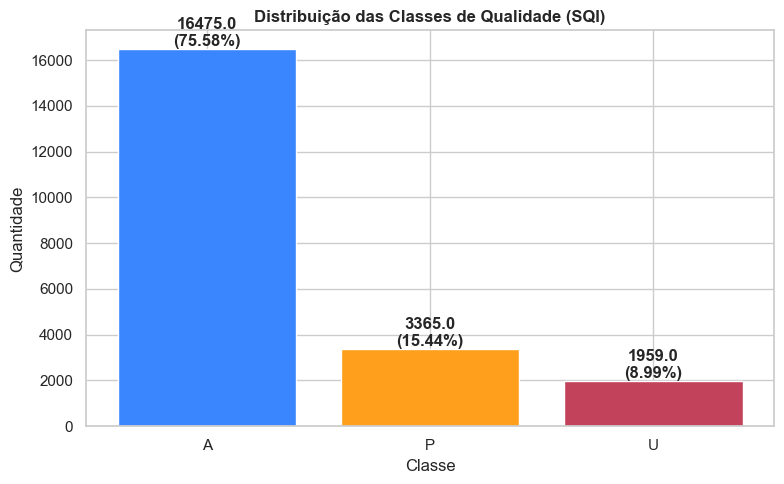

In [19]:
# Aplicação no DataFrame, resumo da classificação e visualização gráfica

# ------------------------------
# Aplicação no DataFrame
# ------------------------------
df_debug = classify_sqi(df_sqi, thresholds, return_debug=True)

df_sqi['quality_class'] = df_debug['quality_class']

# ------------------------------
# Resumo da Classificação
# ------------------------------
ordem = ['G', 'A', 'P', 'U']

dist = df_sqi['quality_class'].value_counts().reindex(ordem)
pct = df_sqi['quality_class'].value_counts(normalize=True).reindex(ordem) * 100

display(Markdown("### Distribuição das Classes de Qualidade (SQI)"))

display(pd.DataFrame({
    'Quantidade': dist,
    'Percentual (%)': pct.round(2)
}))


# ------------------------------
# Visualização da distribuição
# ------------------------------

counts = df_sqi['quality_class'].value_counts().reindex(ordem)
total = counts.sum()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    counts.index,
    counts.values,
    color=['#2d8f4e', '#3a86ff', '#ff9f1c', '#c2425b']
)

# Anotações
for i, v in enumerate(counts.values):
    perc = 100 * v / total
    ax.text(i, v, f'{v}\n({perc:.2f}%)', ha='center', va='bottom', fontweight='bold')

ax.set_title('Distribuição das Classes de Qualidade (SQI)', fontweight='bold')
ax.set_xlabel('Classe')
ax.set_ylabel('Quantidade')

plt.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'distribuicao_classes_de_qualidade_sqi.png'),
    dpi=150,
    bbox_inches='tight'
)

plt.show()

### 3.3 Validação Empírica do Classificador com metadados de qualidade do dataset

Após a definição da lógica de classificação (Seção 3.1) e a otimização dos thresholds (Seção 3.2), foi realizada uma etapa de **validação empírica**, com o objetivo de avaliar o grau de concordância entre a classificação automática e os metadados de qualidade disponíveis no dataset.

---

#### 1. Integração das Classificações

As classes geradas pelo pipeline SQI foram incorporadas ao DataFrame principal, permitindo a análise conjunta entre:

- atributos do sinal  
- presença de problemas anotados  
- classificação final atribuída  

Essa integração é essencial para viabilizar a comparação direta entre o modelo e os dados reais.

---

#### 2. Distribuição das Classes por Presença de Problema

Foi construída uma tabela de contingência entre:

- presença de problema anotado  
- classe atribuída pelo modelo  

Os valores foram normalizados por linha, resultando em percentuais que indicam:

- como sinais **sem problema** estão sendo classificados  
- como sinais **com problema** estão sendo classificados  

Essa análise permite verificar se o modelo está, de fato, separando corretamente sinais bons e ruins.

---

#### 3. Distribuição dos Metadados

Também foi analisada a quantidade total de registros com e sem problemas anotados.

Essa informação é importante pois o dataset pode apresentar **desbalanceamento**, o que impacta diretamente na interpretação das métricas de desempenho.

---

#### 4. Métricas de Concordância

Para quantificar o desempenho do classificador, foram definidas duas categorias auxiliares:

- **Sinais bons:** classes G e A  
- **Sinais ruins:** classes P e U  

A partir disso, foram avaliados dois cenários principais:

- Entre os sinais **sem problema**, qual percentual foi classificado como bom  
- Entre os sinais **com problema**, qual percentual foi classificado como ruim  

Além disso, foi calculada uma métrica global de concordância, representando o percentual total de registros cuja classificação está alinhada com os metadados.

Essa abordagem fornece uma medida direta da capacidade do modelo de:

- **preservar sinais bons**
- **rejeitar sinais degradados**

---

#### 5. Validação por Tipo de Problema

Para aprofundar a análise, foi realizada uma avaliação segmentada por tipo de artefato presente no sinal, incluindo:

- baseline drift  
- ruído estático  
- ruído impulsivo  
- problemas de eletrodo  

Para cada tipo de problema, foi analisada a distribuição das classes:

- G (Excelente)  
- A (Aceitável)  
- P (Processável)  
- U (Inaceitável)  

Essa análise permite observar como o modelo se comporta diante de diferentes tipos de degradação.

---

#### 6. Interpretação dos Resultados

A validação empírica permite identificar padrões importantes no comportamento do classificador:

- Sinais com degradações leves tendem a permanecer em **A (Aceitável)**  
- Sinais com múltiplos artefatos tratáveis tendem a ser classificados como **P (Processáveis)**  
- Sinais severamente degradados são corretamente empurrados para **U (Inaceitáveis)**  

Além disso, é possível verificar se o modelo está:

- sendo **excessivamente permissivo** (aceitando sinais ruins)  
- sendo **excessivamente rigoroso** (rejeitando sinais bons)  

---

#### Justificativa Metodológica

A validação baseada em metadados fornece uma forma prática e eficiente de avaliar o desempenho do classificador em cenários reais, mesmo na ausência de rótulos clínicos detalhados.

Essa abordagem permite:

- verificar a consistência do modelo com anotações existentes  
- identificar possíveis pontos de melhoria  
- validar empiricamente os thresholds otimizados  

Além disso, a análise por tipo de problema oferece uma visão mais granular do comportamento do sistema, permitindo entender **não apenas se o modelo acerta, mas como ele erra**.

Essa etapa é fundamental para garantir que o classificador não apenas funcione bem em termos agregados, mas também apresente comportamento coerente em situações específicas de degradação do sinal.

In [20]:
#Porcentagem de cada categoria SQI, separada por presença de problema nos metadados.

df['quality_class'] = df_sqi['quality_class']

tabela_validacao = pd.crosstab(
    df['has_quality_issues'].replace({True: 'Problema anotado', False: 'Sem problema'}),
    df['quality_class'],
    normalize='index'
) * 100

display(Markdown("**Porcentagem de cada categoria SQI, separada por presença de problema nos metadados:**"))
display(tabela_validacao.round(1))


print(df['has_quality_issues'].value_counts())

df['is_good'] = df['quality_class'].isin(['G', 'A'])
df['is_bad'] = df['quality_class'].isin(['P', 'U'])

# Concordâncias
sem_prob = df[~df['has_quality_issues']]
com_prob = df[df['has_quality_issues']]

taxa_bons_limpos = sem_prob['is_good'].mean() * 100
taxa_ruins_sujos = com_prob['is_bad'].mean() * 100

acertos = sem_prob['is_good'].sum() + com_prob['is_bad'].sum()
acuracia_real = acertos / len(df) * 100

display(Markdown(f"""
**Concordância:**
- Dos registros **sem** problema anotado, **{taxa_bons_limpos:.1f}%** foram classificados como G ou A.
- Dos registros **com** problema anotado, **{taxa_ruins_sujos:.1f}%** caíram em P ou U.
- Dos registros totais, **{acuracia_real:.1f}%** estiveram em classes que corroboram com os metadados de qualidade.
"""))

**Porcentagem de cada categoria SQI, separada por presença de problema nos metadados:**

quality_class,A,P,U
has_quality_issues,,,
Problema anotado,68.7,20.7,10.7
Sem problema,77.6,13.9,8.5


has_quality_issues
False    16789
True      5010
Name: count, dtype: int64



**Concordância:**
- Dos registros **sem** problema anotado, **77.6%** foram classificados como G ou A.
- Dos registros **com** problema anotado, **31.3%** caíram em P ou U.
- Dos registros totais, **67.0%** estiveram em classes que corroboram com os metadados de qualidade.


In [21]:
# Validação por detecção por tipo de problema

display(Markdown("### Detecção por tipo de problema"))

resultados = []
problemas = [ 'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems' ]
ordem = ['G', 'A', 'P', 'U']

for prob in problemas:
    mask = df[prob].notna()
    total = mask.sum()

    contagem = (
        df.loc[mask, 'quality_class']
        .value_counts()
        .reindex(ordem, fill_value=0)
    )

    resultados.append({
        'Problema': prob,
        'G': f"{contagem['G']} ({100*contagem['G']/total:.2f}%)",
        'A': f"{contagem['A']} ({100*contagem['A']/total:.2f}%)",
        'P': f"{contagem['P']} ({100*contagem['P']/total:.2f}%)",
        'U': f"{contagem['U']} ({100*contagem['U']/total:.2f}%)",
        'Total': total
    })

df_resultados_final = pd.DataFrame(resultados) 
display(df_resultados_final.round(2))

### Detecção por tipo de problema

,Problema,G,A,P,U,Total
0,baseline_drift,0 (0.00%),587 (36.73%),690 (43.18%),321 (20.09%),1598
1,static_noise,0 (0.00%),2621 (80.40%),418 (12.82%),221 (6.78%),3260
2,burst_noise,0 (0.00%),444 (72.43%),99 (16.15%),70 (11.42%),613
3,electrodes_problems,0 (0.00%),19 (63.33%),6 (20.00%),5 (16.67%),30


**Comentários sobre a subseção 3.3:**

Os resultados obtidos indicam um comportamento **coerente, porém ainda pouco discriminativo** do classificador.

De forma geral, observa-se um bom desempenho na **preservação de sinais de qualidade**, com **77,6% dos registros sem problema** sendo classificados como **G ou A**, o que demonstra baixa taxa de rejeição indevida. Isso sugere que o modelo é eficaz em evitar o descarte de sinais potencialmente úteis.

Por outro lado, a capacidade de identificar sinais degradados ainda é limitada: apenas **31,3% dos registros com problema** foram classificados como **P ou U**, indicando que uma parcela significativa de sinais com artefatos ainda está sendo considerada aceitável.

A acurácia global de **67,0%** reforça essa leitura, evidenciando um classificador **mais permissivo do que o ideal**, com tendência a priorizar o aproveitamento dos dados em detrimento de uma filtragem mais rigorosa.

---

#### Análise por Tipo de Problema

A avaliação segmentada por tipo de artefato revela padrões importantes no comportamento do modelo:

- **Baseline Drift**
  - Forte concentração em **P (43,18%)** e **U (20,09%)**
  - Indica que o modelo reconhece bem esse tipo de degradação como **ruído tratável ou severo**
  - Comportamento esperado, já que drift é tipicamente corrigível via filtragem

- **Static Noise**
  - Predominância de **A (80,40%)**
  - Baixa taxa de P e U
  - Sugere que o modelo considera esse ruído como **pouco impactante na estrutura do sinal**, sendo mais tolerante

- **Burst Noise**
  - Distribuição mais equilibrada:
    - **A (72,43%)**
    - **P (16,15%)**
    - **U (11,42%)**
  - Indica sensibilidade moderada, mas ainda com tendência permissiva

- **Electrodes Problems**
  - Maior dispersão entre classes:
    - **A (63,33%)**
    - **P (20,00%)**
    - **U (16,67%)**
  - Pode indicar dificuldade em capturar corretamente esse tipo de artefato, possivelmente por baixa representatividade no dataset ou ainda difícil identificação com as métricas de SQI escolhidas.

Um ponto importante é a **ausência total de classificações como G (Excelente)** nesses subconjuntos, o que é coerente, já que todos envolvem algum tipo de degradação anotada e, por mais que a decisão de parâmetros para sinais serem considerados G tenham afrouxado ao longo de múltiplos testes do algoritmo, os parâmetros atuais acabaram por excluídos por completo.

---

#### Considerações sobre o Processo de Ajuste

É fundamental destacar que a definição das regras de decisão entre as classes **G, A, P e U** foi resultado de um processo **extensivo e iterativo de experimentação**.

Foram realizados:

- Testes com diferentes estruturas de decisão  
- Ajustes sucessivos nas regras heurísticas  
- Exploração sistemática de variações nos thresholds (Seção 3.2)  

Esse processo teve como objetivo equilibrar dois aspectos centrais:

- **Maximizar o aproveitamento de sinais de boa qualidade**  
- **Minimizar a aceitação de sinais degradados**  

Mesmo após esse refinamento exaustivo, os resultados evidenciam a complexidade do problema, especialmente na distinção entre sinais **aceitáveis (A)** e **degradados porém utilizáveis (P)**.

---

#### Síntese

Em conjunto, os resultados indicam que o classificador:

- É **conservador na rejeição de sinais bons**  
- É **permissivo na aceitação de sinais com ruído**  
- Apresenta bom entendimento de **degradações tratáveis (ex.: baseline drift)**  
- Ainda tem limitações na identificação de **ruídos mais sutis ou ambíguos**

Essas características são consistentes com a filosofia adotada no modelo:

> **Priorizar a preservação da informação, mesmo sob presença de ruído — desde que a estrutura fisiológica do sinal permaneça íntegra.**

---

## Seção 4 — Visualizações Comparativas

Nesta seção, são apresentadas visualizações exploratórias com o objetivo de analisar o comportamento das métricas de qualidade do sinal de ECG sob diferentes perspectivas. Por meio de gráficos e comparações visuais, busca-se identificar padrões, relações entre variáveis e possíveis redundâncias entre indicadores utilizados no processo de classificação.

As análises aqui desenvolvidas complementam a modelagem proposta anteriormente, oferecendo uma interpretação mais intuitiva dos dados e permitindo avaliar, na prática, a coerência dos critérios adotados. Além disso, essas visualizações auxiliam na validação das escolhas metodológicas, evidenciando como as métricas se distribuem, interagem entre si e contribuem para a separação entre diferentes níveis de qualidade do sinal.

Em conjunto, esta seção fortalece a compreensão do sistema proposto, servindo como ponte entre a definição teórica dos critérios e sua manifestação empírica nos dados.

### 4.1 Painel Comparativo: Extremos de Qualidade do Classificador

Nesta etapa, são visualizados lado a lado registros representativos dos **extremos do classificador de qualidade**, permitindo uma análise qualitativa do comportamento do modelo frente a diferentes níveis de degradação do sinal.

Diferentemente de uma amostragem aleatória, os sinais foram selecionados com base em uma **ordenação multi-critério**, utilizando as métricas internas do sistema para identificar exemplos mais representativos de cada extremo:

- **Registros de alta qualidade (G ou A)** com:
  - maior número de critérios satisfeitos (*score_G elevado*)
  - menor número de falhas (*score_A_fail baixo*)
  - baixa presença de artefatos (*corrigivel baixo*)

- **Registros de baixa qualidade (U ou P)** com:
  - menor aderência a critérios de qualidade (*score_G baixo*)
  - maior número de falhas (*score_A_fail elevado*)
  - maior acúmulo de degradações (*corrigivel alto*)

Essa estratégia garante que os sinais selecionados não sejam apenas exemplos típicos, mas sim **casos extremos dentro do espaço de decisão do modelo**, evidenciando com maior clareza os padrões utilizados na classificação.

Para cada sinal, são apresentados:

- **Forma de onda (derivação DII)** → avaliação visual da morfologia cardíaca  
- **Espectro de potência (Welch)** → identificação de ruídos e distribuição de frequência  
- **Histograma de amplitude** → análise da distribuição estatística do sinal  

Essa abordagem permite verificar, de forma visual e interpretável, se os critérios definidos pelo classificador correspondem a diferenças reais na qualidade dos sinais.

Em particular, espera-se observar que:

- Sinais de alta qualidade apresentam **complexos QRS bem definidos**, **baixo ruído**, **linha de base estável** e **espectro concentrado**
- Sinais de baixa qualidade apresentam **distorções morfológicas**, **desvio de linha de base**, **ruído significativo** e **distribuição espectral mais difusa**

Dessa forma, o painel atua como uma **validação qualitativa do modelo**, complementando as métricas quantitativas e permitindo avaliar a coerência entre os critérios heurísticos adotados e a aparência real dos sinais de ECG.

**Comparação entre extremos do classificador:** os sinais em verde representam os melhores registros disponíveis (priorizando classe G, com fallback para A), enquanto os sinais em vermelho representam os piores registros (priorizando classe U, com fallback para P). A seleção é baseada nas métricas internas do modelo, garantindo uma visualização representativa dos limites de qualidade do dataset.

Comentando brevemente os sinais gerados, podemos ver que a diferença entre os sinais vermelhos e verdes é mais evidente principalmente no que diz respeito ao desvio de linha de base e arritmias: 
- enquanto os sinais em verde apresenta uma linha de base relativamente estável e com desvio quase imperceptível, os sinais em vermelho ( em especial os ECG's 2240 e 7012 ) apresentam um desvio bastanteacentuado, até mesmo caótico 
- ao mesmo tempo, a regularidade do espaçamento entre ondas R é muito maior nas amostras verdes, por mais que os valores de mV de cada um se diferencie bastante entre si ( arrisco-me ainda a dizer que as ondas S, extremamente acentuadas no ECG 447, podem indicar alguma patologia cardíaca ). Nos sinais vermelhos é possível notar espaçamentos grandes e irregulares entre ondas R, o que estranhamente não refletiu em um valor de qSQI ruim ( como podemos ver, eles estão até melhores que os de algumas das verdes ). Essa métrica aparentemente boa provavelmente se dá por conta do qSQI utilizado ser uma média de todos os tirados por sinal, o que curiosamente nos mostra que, por mais que a métrica seja boa e eficaz, erros acumulados podem acabar disfarçando um sinal ruim de um sinal bom!

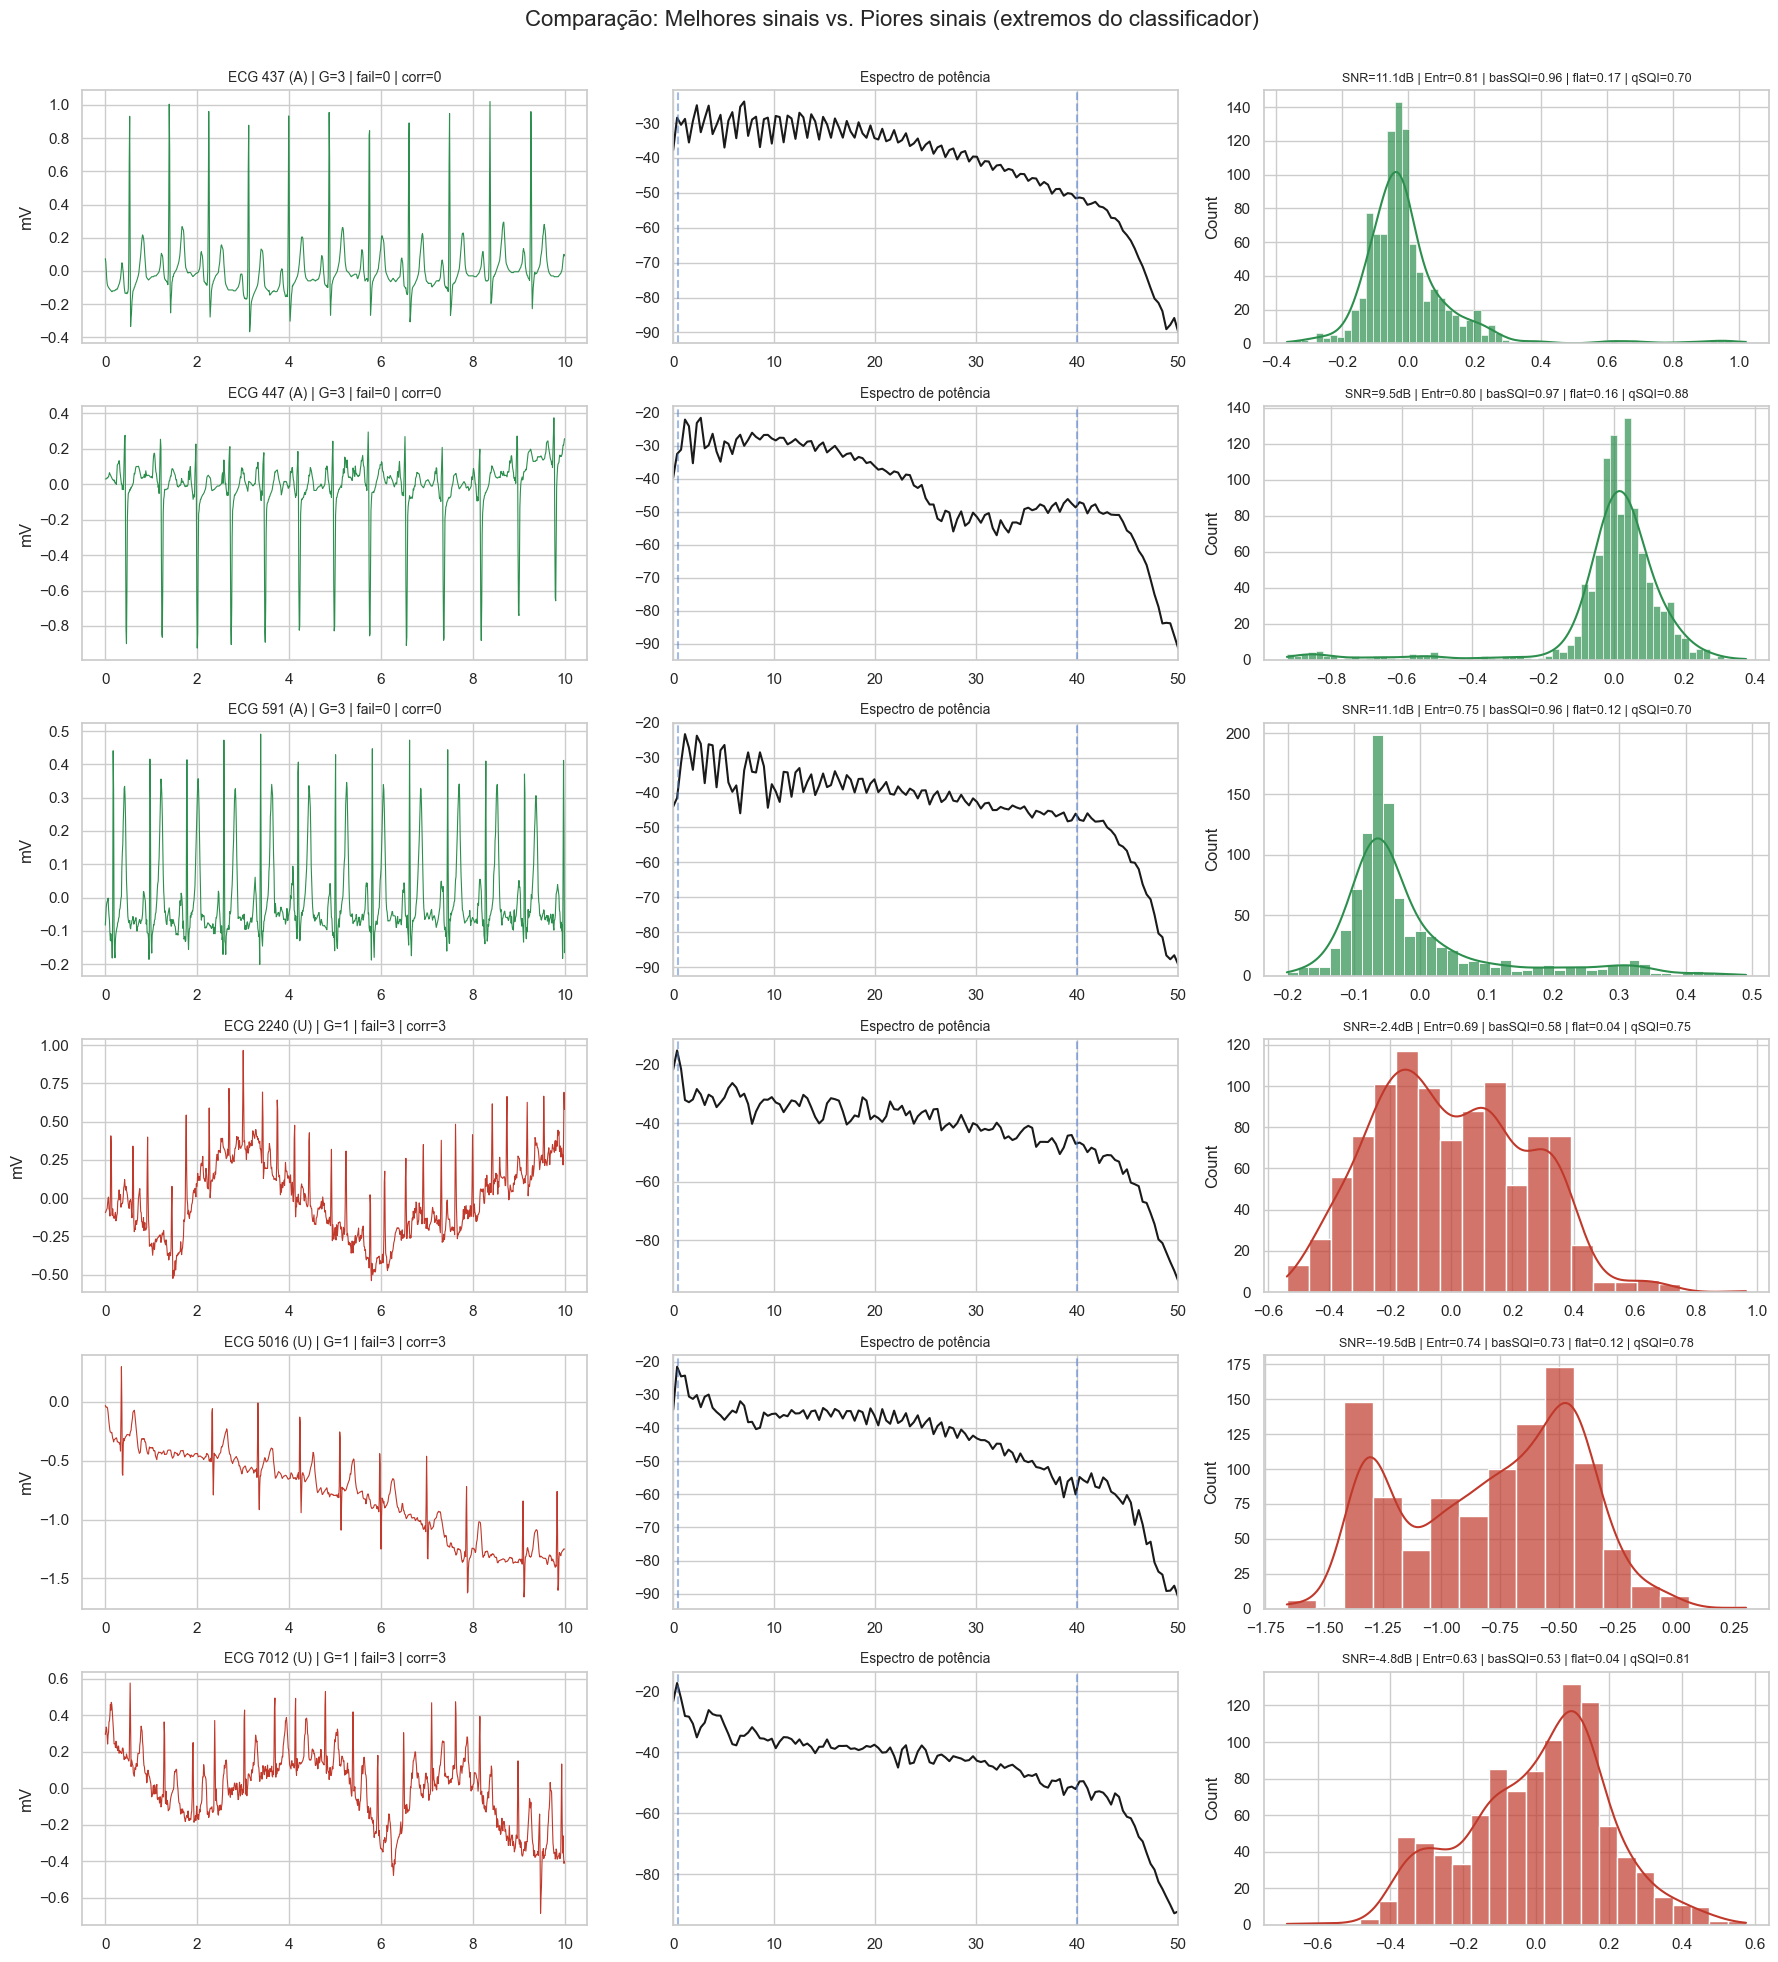

In [27]:
# Seleção comparativa de extremos 

df_plot = df_sqi.copy()
df_plot[['corrigivel', 'score_G', 'score_A_fail']] = df_debug[['corrigivel', 'score_G', 'score_A_fail']]

# --- MELHORES (G -> fallback A) ---
if (df_plot['quality_class'] == 'G').sum() >= 3:
    melhores = (
        df_plot[df_plot['quality_class'] == 'G']
        .sort_values(['score_G', 'score_A_fail', 'corrigivel'], ascending=[False, True, True])
        .head(3)
        .index
    )
else:
    melhores = (
        df_plot[df_plot['quality_class'] == 'A']
        .sort_values(['score_G', 'score_A_fail', 'corrigivel'], ascending=[False, True, True])
        .head(3)
        .index
    )

# --- PIORES (U -> fallback P) ---
if (df_plot['quality_class'] == 'U').sum() >= 3:
    piores = (
        df_plot[df_plot['quality_class'] == 'U']
        .sort_values(['score_G', 'score_A_fail', 'corrigivel'], ascending=[True, False, False])
        .head(3)
        .index
    )
else:
    piores = (
        df_plot[df_plot['quality_class'] == 'P']
        .sort_values(['Score_G', 'corrigivel', 'score_A_fail'], ascending=[True, False, False])
        .head(3)
        .index
    )

amostrados = list(melhores) + list(piores)

# ------------------------------
# Plot
# ------------------------------

fig, axes = plt.subplots(6, 3, figsize=(18, 20))
fig.suptitle('Comparação: Melhores sinais vs. Piores sinais (extremos do classificador)', fontsize=16)

for i, eid in enumerate(amostrados):
    sig = load_ecg(eid, df, DATA_DIR, FS)
    dii = sig[:, 1]
    t = np.arange(len(dii)) / FS

    cor = '#2d8f4e' if i < 3 else '#c0392b'
    row = df_plot.loc[eid]

    # Coluna 1: Sinal
    axes[i, 0].plot(t, dii, color=cor, lw=0.8)
    axes[i, 0].set_title(
        f'ECG {eid} ({row["quality_class"]}) | G={row["score_G"]:.0f} | fail={row["score_A_fail"]:.0f} | corr={row["corrigivel"]:.0f}',
        fontsize=10
    )
    axes[i, 0].set_ylabel('mV')

    # Coluna 2: Espectro
    freqs, psd = signal.welch(dii, fs=FS, nperseg=256)
    axes[i, 1].plot(freqs, 10 * np.log10(psd + 1e-10), color='k')
    axes[i, 1].axvline(0.5, linestyle='--', alpha=0.5)
    axes[i, 1].axvline(40, linestyle='--', alpha=0.5)
    axes[i, 1].set_xlim(0, 50)
    axes[i, 1].set_title('Espectro de potência', fontsize=10)

    # Coluna 3: Histograma
    sns.histplot(dii, kde=True, ax=axes[i, 2], color=cor, alpha=0.7)

    info = (
        f"SNR={row['snr_db']:.1f}dB | "
        f"Entr={row['spectral_entropy']:.2f} | "
        f"basSQI={row['basSQI_mean']:.2f} | "
        f"flat={row['flat_ratio_max']:.2f} | "
        f"qSQI={row['qSQI_mean']:.2f}"
    )
    axes[i, 2].set_title(info, fontsize=9)

plt.tight_layout()
plt.subplots_adjust(top=0.94)

fig.savefig(
    os.path.join(FIGS_DIR, 'painel_extremos_sqi.png'),
    dpi=150,
    bbox_inches='tight'
)

display(Markdown(
"**Comparação entre extremos do classificador:** os sinais em verde representam os melhores registros disponíveis "
"(priorizando classe G, com fallback para A), enquanto os sinais em vermelho representam os piores registros "
"(priorizando classe U, com fallback para P). A seleção é baseada nas métricas internas do modelo, garantindo "
"uma visualização representativa dos limites de qualidade do dataset."
))
display(Markdown(
    "Comentando brevemente os sinais gerados, podemos ver que a diferença entre os sinais vermelhos e verdes "
    "é mais evidente principalmente no que diz respeito ao desvio de linha de base e arritmias: \n"
    "- enquanto os sinais em verde apresenta uma linha de base relativamente estável e com desvio quase "
    "imperceptível, os sinais em vermelho ( em especial os ECG's 2240 e 7012 ) apresentam um desvio bastante"
    "acentuado, até mesmo caótico \n"
    "- ao mesmo tempo, a regularidade do espaçamento entre ondas R é muito maior nas amostras verdes, por mais "
    "que os valores de mV de cada um se diferencie bastante entre si ( arrisco-me ainda a dizer que as ondas S, "
    "extremamente acentuadas no ECG 447, podem indicar alguma patologia cardíaca ). Nos sinais vermelhos é possível "
    "notar espaçamentos grandes e irregulares entre ondas R, o que estranhamente não refletiu em um valor de qSQI "
    "ruim ( como podemos ver, eles estão até melhores que os de algumas das verdes ). Essa métrica aparentemente boa "
    "provavelmente se dá por conta do qSQI utilizado ser uma média de todos os tirados por sinal, o que curiosamente "
    "nos mostra que, por mais que a métrica seja boa e eficaz, erros acumulados podem acabar disfarçando um sinal ruim "
    "de um sinal bom!"        

))
plt.show()



### 4.2 Mapa de Calor de Correlação entre Métricas SQI

O mapa de correlação permite identificar relações entre as métricas de qualidade.

Métricas com **alta correlação (|r| elevado)** tendem a capturar o mesmo tipo de degradação no sinal, indicando possível redundância.  
Já métricas com **baixa correlação** são desejáveis, pois contribuem com informações complementares para a avaliação da qualidade.

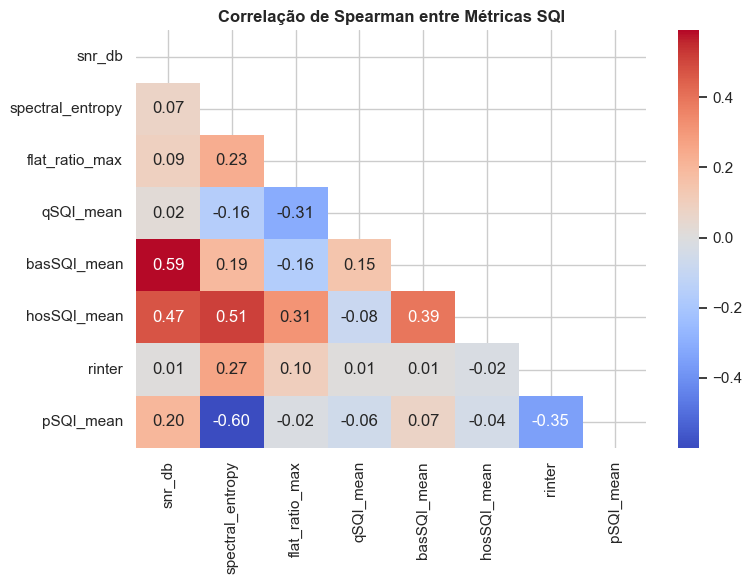

In [40]:
# Cálculo do mapa de calor de correlação entre métricas SQI

fig = plt.figure(figsize=(8, 6))

cols_sqi = [
    'snr_db',
    'spectral_entropy',
    'flat_ratio_max',
    'qSQI_mean',
    'basSQI_mean',
    'hosSQI_mean',
    'rinter',
    'pSQI_mean'
]

corr_sqi = df_sqi[cols_sqi].corr(method='spearman')

sns.heatmap(
    corr_sqi,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    mask=np.triu(np.ones_like(corr_sqi, dtype=bool))
)

plt.title('Correlação de Spearman entre Métricas SQI', fontweight='bold')
plt.tight_layout()

plt.savefig(
    os.path.join(FIGS_DIR, 'correlacao_sqi.png'),
    dpi=150,
    bbox_inches='tight'
)

plt.show()

**Comentários sobre a subseção 4.2:**

A análise do mapa de correlação entre as métricas SQI indica, de forma geral, um conjunto bem distribuído e complementar de indicadores de qualidade. Não foram observadas correlações muito altas (|r| > 0.7), o que sugere baixa redundância entre as métricas e reforça a adequação do conjunto escolhido.

Algumas relações moderadas merecem destaque. A correlação negativa entre `spectral_entropy` e `pSQI_mean` (r ≈ -0.60) é coerente do ponto de vista fisiológico, uma vez que sinais mais desorganizados espectralmente tendem a apresentar menor concentração de energia na banda característica do ECG. De forma semelhante, a correlação positiva entre `snr_db` e `basSQI_mean` (r ≈ 0.59) indica que ambas capturam aspectos relacionados à qualidade global do sinal, embora ainda não de forma redundante.

Outras associações, como entre `spectral_entropy` e `hosSQI_mean` (r ≈ 0.51), sugerem que ruídos espectrais também impactam a morfologia do sinal, enquanto a correlação negativa entre `flat_ratio_max` e `qSQI_mean` (r ≈ -0.31) evidencia que trechos com perda de sinal afetam diretamente a regularidade dos intervalos RR.

Por outro lado, métricas como `qSQI_mean` e `rinter` apresentaram baixa correlação com as demais, indicando que contribuem com informações praticamente independentes — característica altamente desejável em sistemas de fusão heurística.

Em síntese, os resultados corroboram que o conjunto de métricas adotado é consistente, abrangendo diferentes dimensões da qualidade do sinal (ruído, estrutura, morfologia e artefatos), sem apresentar redundâncias significativas.

### 4.3 Distribuição do SNR por Categoria e Derivação

A análise da relação sinal-ruído (*Signal-to-Noise Ratio – SNR*) constitui uma etapa fundamental na avaliação da qualidade de sinais de ECG, uma vez que esse indicador sintetiza o grau de contaminação por ruído em relação ao conteúdo fisiológico útil.

Nesta subseção, busca-se investigar como o SNR se distribui tanto entre as diferentes categorias de qualidade atribuídas pelo classificador quanto entre as derivações do ECG. Essa análise permite compreender, de forma exploratória, se há padrões consistentes de separação entre sinais de diferentes qualidades e identificar possíveis variações estruturais entre os canais de aquisição.

Além disso, a avaliação por derivação possibilita verificar se determinadas posições do eletrodo estão mais suscetíveis a ruídos ou artefatos, o que pode impactar diretamente a robustez das métricas utilizadas e orientar futuras estratégias de processamento ou ponderação das derivações.

SNR por derivação: 100%|██████████| 500/500 [00:07<00:00, 63.57it/s]


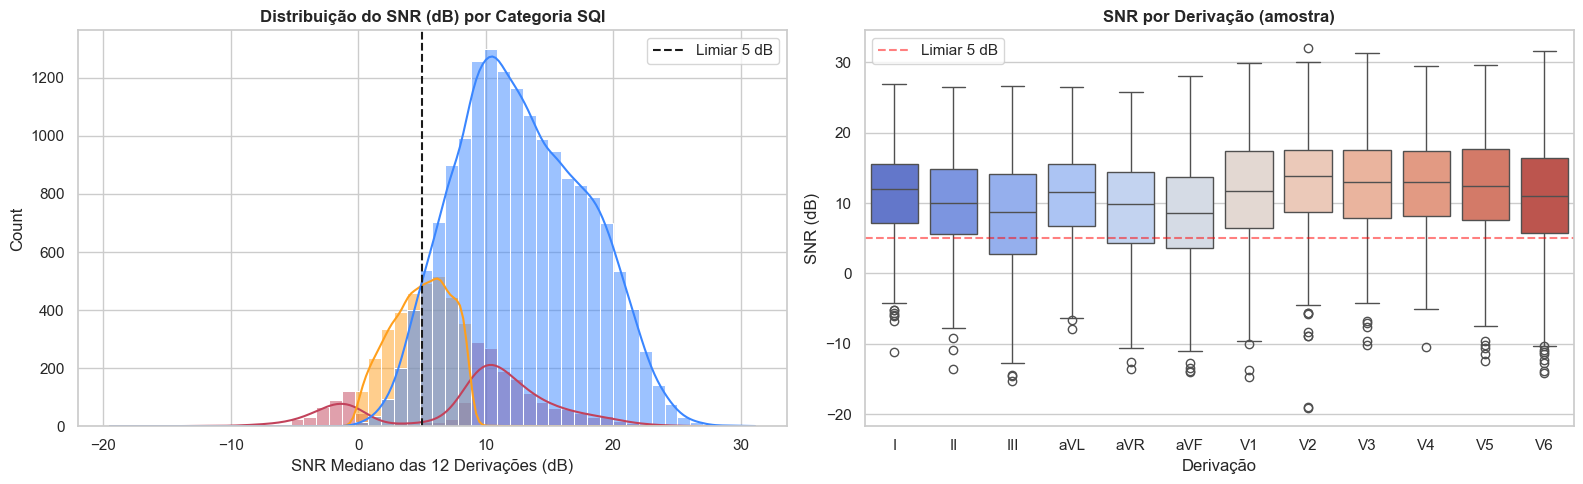

In [ ]:
# Distribuição do SNR (Signal-to-Noise Ratio) por categoria do SQI e derivação dos ECG's

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# -------------------------
# 1. Distribuição do SNR
# -------------------------
sns.histplot(
    data=df_sqi,
    x='snr_db',
    hue='quality_class',
    bins=50,
    kde=True,
    palette={'G': '#2d8f4e','A': '#3a86ff','P': '#ff9f1c', 'U': '#c2425b'},
    ax=axes[0]
)

axes[0].set_title('Distribuição do SNR (dB) por Categoria SQI', fontweight='bold')
axes[0].set_xlabel('SNR Mediano das 12 Derivações (dB)')
axes[0].axvline(5, color='k', linestyle='--', label='Limiar 5 dB')
axes[0].legend()

# -------------------------
# 2. SNR por derivação
# -------------------------

# Amostra
amostra_snr_lead = df.sample(min(500, len(df)), random_state=42).index
snr_por_lead = []

nyq = 0.5 * FS
b_bp, a_bp = signal.butter(4, [0.5/nyq, 40/nyq], btype='bandpass')

for eid in tqdm(amostra_snr_lead, desc='SNR por derivação'):
    sig = load_ecg(eid, df, DATA_DIR, FS)
    s_clean = signal.filtfilt(b_bp, a_bp, sig, axis=0)
    noise = sig - s_clean

    rms_c = np.sqrt(np.mean(s_clean**2, axis=0))
    rms_n = np.sqrt(np.mean(noise**2, axis=0))
    rms_n = np.where(rms_n == 0, 1e-10, rms_n)

    snr_leads = 10 * np.log10((rms_c**2) / (rms_n**2))

    for j, lead in enumerate(LEAD_NAMES):
        snr_por_lead.append({'lead': lead, 'snr_db': snr_leads[j]})

df_snr_leads = pd.DataFrame(snr_por_lead)

sns.boxplot(
    data=df_snr_leads,
    x='lead',
    y='snr_db',
    hue='lead',
    order=LEAD_NAMES,
    palette='coolwarm',
    ax=axes[1]
)

axes[1].axhline(5, color='red', linestyle='--', alpha=0.5, label='Limiar 5 dB')
axes[1].set_title('SNR por Derivação (amostra)', fontweight='bold')
axes[1].set_xlabel('Derivação')
axes[1].set_ylabel('SNR (dB)')
axes[1].legend()

# -------------------------
# Finalização
# -------------------------
plt.tight_layout()

plt.savefig(
    os.path.join(FIGS_DIR, 'snr_analise_completa.png'),
    dpi=150,
    bbox_inches='tight'
)

plt.show()

**Comentários sobre a subseção 4.3:**

A distribuição do SNR por classe de qualidade evidencia uma separação coerente com a lógica do classificador. Registros classificados como **A (Aceitável)** concentram-se majoritariamente em valores mais altos de SNR, indicando sinais limpos e com boa relação sinal-ruído. Já as classes **P (Processável)** e **U (Inaceitável)** apresentam maior dispersão e presença significativa em regiões de baixo SNR, o que reforça a associação entre ruído e degradação da qualidade.

Observa-se que o limiar de **5 dB** atua como um ponto de transição razoável: abaixo dele, há predominância de sinais problemáticos, enquanto acima, especialmente na faixa de 10–20 dB, concentram-se os sinais de melhor qualidade. No entanto, a sobreposição entre classes indica que o SNR isoladamente não é suficiente para discriminação perfeita — justificando o uso combinado de múltiplas métricas no classificador.

No gráfico por derivação, nota-se que o SNR varia entre os canais, mas de forma relativamente consistente. Algumas derivações (como V1–V3) tendem a apresentar maior variabilidade e presença de outliers negativos, possivelmente devido a maior suscetibilidade a ruídos de movimento e posicionamento torácico. Ainda assim, todas as derivações mantém mediana acima do limiar de 5 dB (com a maioria mantendo até mesmo ambos os quartis acima desse limiar), indicando qualidade geral aceitável na maior parte dos registros.

Em conjunto, os resultados reforçam que:
- O SNR é um bom indicador global de qualidade
- Existe variabilidade entre derivações, mas sem degradações sistemáticas graves
- A combinação com outras métricas é essencial para uma avaliação robusta

---

## Seção 5 — Salvamento e Síntese

Nesta etapa final, consolidamos os resultados do pipeline de avaliação de qualidade, integrando as métricas SQI calculadas e as classificações atribuídas a cada registro.

Os dados processados são então organizados e exportados, incluindo tanto as métricas individuais quanto a classe de qualidade final (**G, A, P, U**) associada a cada sinal. Essa estrutura permite rastreabilidade completa entre os indicadores calculados e a decisão tomada pelo sistema.

Além disso, são identificados e separados os registros considerados inadequados para análise direta — seja por degradação irreversível (**U**) ou por necessidade de processamento prévio (**P**).

Para as próximas etapas do projeto, o foco será direcionado aos sinais de maior qualidade (**G e A**), que apresentam condições adequadas para análise clínica e modelagem. Já os registros classificados como **P** poderão ser posteriormente recuperados por técnicas de filtragem, enquanto os **U** tendem a ser descartados do fluxo principal.

Essa separação garante um equilíbrio entre **qualidade dos dados, aproveitamento da base e robustez das análises subsequentes**.

In [50]:
# Separação e salvamento das descobertas

caminho_final = '../outputs/ptbxl_com_sqi.csv'
df.to_csv(caminho_final)

# Lista de rejeitados
rejeitados = df[df['quality_class'] == 'U']
cam_rejeitados = '../outputs/rejected_ecg_ids.txt'

with open(cam_rejeitados, 'w') as fh:
    for item in rejeitados.index:
        fh.write(f"{item}\n")

# Contagem por classe
n_g = len(df[df['quality_class'] == 'G'])
n_a = len(df[df['quality_class'] == 'A'])
n_p = len(df[df['quality_class'] == 'P'])
n_u = len(df[df['quality_class'] == 'U'])

display(Markdown(f"""
**Arquivos salvos:**
- Dataset com SQI: `{caminho_final}`
- IDs rejeitados: `{cam_rejeitados}`

**Resumo por categoria:**

| Categoria | Registros | Descrição |
|---|---|---|
| G (Alta qualidade) | {n_g} | Aprovados para o pipeline |
| A (Aceitáveis) | {n_a} | Utilizáveis com boa confiabilidade |
| P (Processáveis) | {n_p} | Recuperáveis por processamento de sinais |
| U (Irrecuperáveis) | {n_u} | Excluídos do pipeline |

"""))


**Arquivos salvos:**
- Dataset com SQI: `../outputs/ptbxl_com_sqi.csv`
- IDs rejeitados: `../outputs/rejected_ecg_ids.txt`

**Resumo por categoria:**

| Categoria | Registros | Descrição |
|---|---|---|
| G (Alta qualidade) | 0 | Aprovados para o pipeline |
| A (Aceitáveis) | 16475 | Utilizáveis com boa confiabilidade |
| P (Processáveis) | 3365 | Recuperáveis por processamento de sinais |
| U (Irrecuperáveis) | 1959 | Excluídos do pipeline |



**Comentário final:**

Observa-se que a grande maioria dos registros foi classificada como **Aceitável (A)**, enquanto nenhum sinal atingiu o nível **Excelente (G)**. Isso sugere que o critério para excelência está bastante rigoroso, possivelmente exigindo condições ideais raramente encontradas em dados clínicos reais.

Por outro lado, a soma das classes **G + A** representa aproximadamente **75,6%** do dataset, indicando que uma parcela significativa dos sinais ainda é utilizável para análise, o que é desejável em bases reais coletadas ao longo de longos períodos e sob condições não controladas.

A presença de cerca de **15,4%** de sinais **Processáveis (P)** reforça a importância de etapas futuras de filtragem, já que esses registros ainda possuem informação útil recuperável. Já os **9,0%** classificados como **Inaceitáveis (U)** indicam uma taxa de rejeição moderada, coerente com a variabilidade esperada em dados clínicos.

De forma geral, o sistema apresenta um bom equilíbrio entre **rigor na exclusão de sinais inviáveis** e **aproveitamento dos dados disponíveis**, embora possa ser interessante, em etapas futuras, ajustar levemente os critérios de excelência para evitar a ausência total de registros classificados como **G** ou, ainda, reavaliar o SQI após filtragem dos sinais considerados **P** em busca de potenciais **G**'s emergentes.